In [1]:
# import sys
# print(sys.path)

In [1]:
import sys

import pandas as pd

sys.path.insert(0, '..')
print(sys.path)

['..', '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina', '/Users/neuralrehabilitationgroup/PycharmProjects/SingularSuperletPY', '/opt/anaconda3/envs/Superlets-Marina/lib/python38.zip', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/lib-dynload', '', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/site-packages', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/site-packages/setuptools/_vendor']


In [2]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import importlib
import scipy.signal as signal_scipy
import os

import cmcrameri.cm as cmc
from scipy.ndimage import gaussian_filter1d

import superlets_package.morlet as morlet
import superlets_package.superlets as superlet

from SingularSuperletPY import sst
from SingularSuperletPY import cwt


In [3]:
importlib.reload(superlet)

<module 'superlets_package.superlets' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/demo/../superlets_package/superlets.py'>

In [4]:
importlib.reload(morlet)

<module 'superlets_package.morlet' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/demo/../superlets_package/morlet.py'>

# Load EMG signal

In [5]:
folder_out = "/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/REAL_SIGNAL"

In [6]:
data = pd.read_csv(os.path.join(folder_out,'subject_56_cond_02_run_06_EMG.csv'))
# emg = data['x_resampled']
# emg = np.squeeze(emg)
# emg = np.load("/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/signal_burst_1.npy")

In [7]:
emg = data['Sol_r']
array_np = emg.values 
# Pasamos a milivoltios
emg = jnp.array(array_np) * 1000

In [8]:
emg

DeviceArray([0.00269902, 0.00179097, 0.00178167, ..., 0.00069071,
             0.00829242, 0.01664868], dtype=float32)

### Signal parameters

In [9]:
if len(emg) > 12000:
    emg = emg[11000:12000]

In [10]:
Fs = 2000
signal_duration = len(emg)/Fs
t = np.linspace(0, len(emg)/Fs, len(emg))

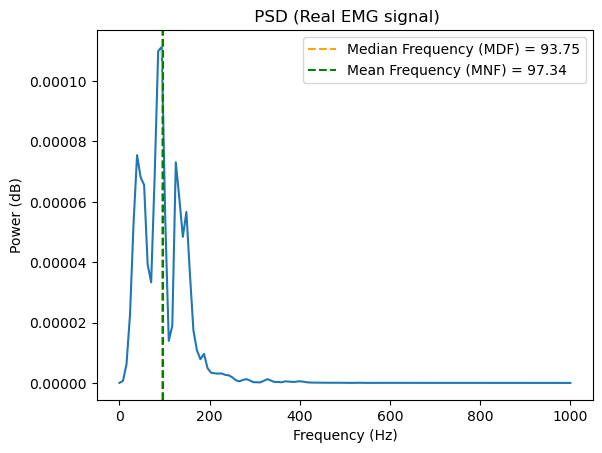

In [11]:
psd_welch, f_welch, MNF = superlet.compute_psd_welch(emg, Fs, plot=True, muscle='Real EMG signal')
MNF_1 = [MNF]

In [12]:
# hp = 20
# lp = 500
# order = 2
# 
# w1 = (2 / fs) * hp
# w2 = (2 / fs) * lp
# b, a = signal_scipy.butter(order, [w1, w2], btype='bandpass')
# filtered_emg = signal_scipy.filtfilt(b, a, emg)
# 
# harm = 20
# pli = 50
# 
# # Notch filter to remove PLI interference
# w1 = (2 / fs) * (pli-1)
# w2 = (2 / fs) * (pli+1)
# b, a = signal_scipy.butter(3, [w1, w2], btype='stop')
# filtered_emg = signal_scipy.filtfilt(b, a, emg)
# filtered_emg_demeaned = filtered_emg - np.mean(filtered_emg, axis=0)
# emg = filtered_emg_demeaned

In [13]:
fontsize_title = 10
fontsize_subtitle = 16
fontsize_ticks = 12
fontsize_labels = 14
fontsize_legend = 14

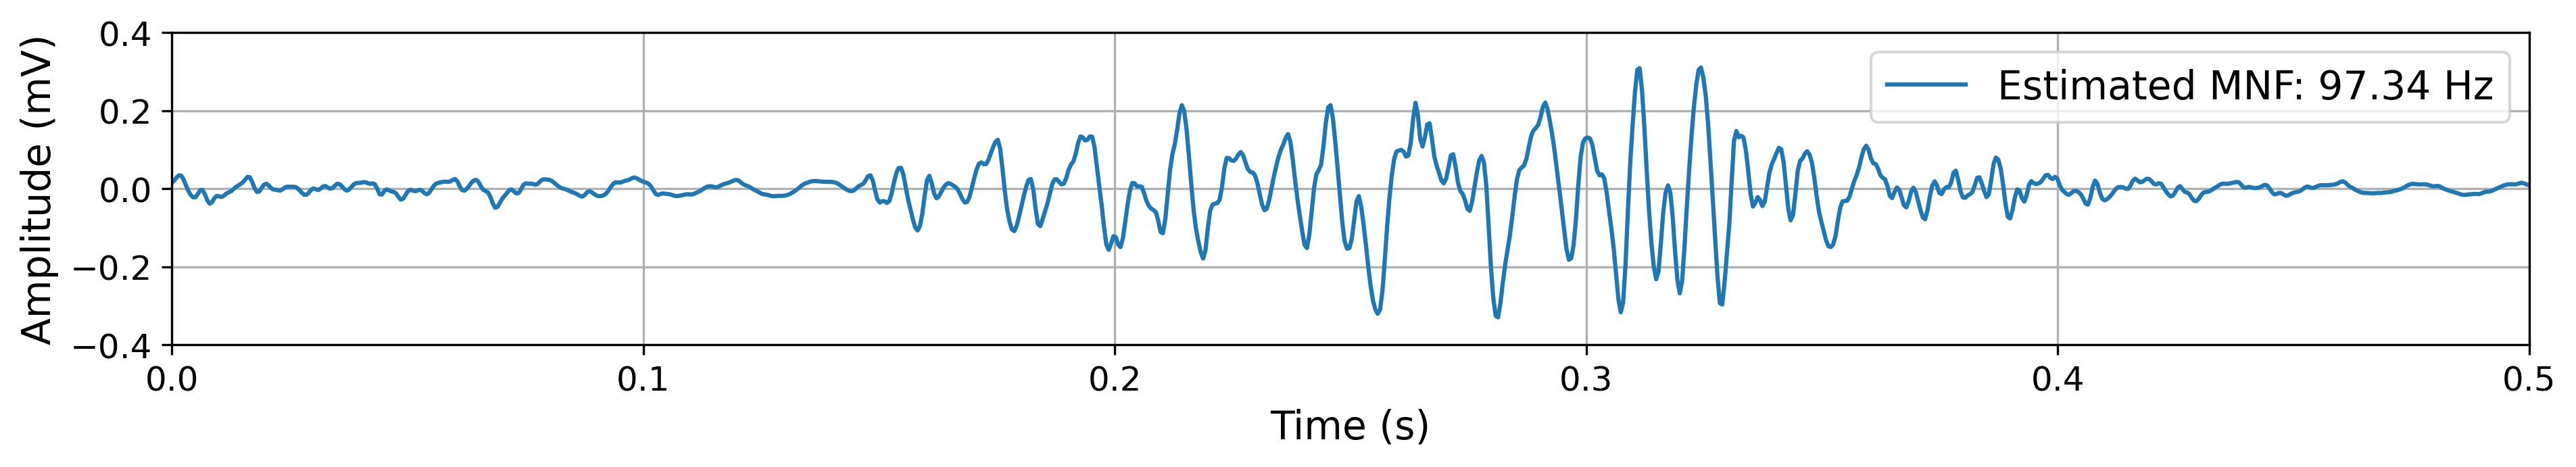

In [14]:
fig, ax = plt.subplots(figsize=(15, 2), dpi=300)
ax.set_xlabel("Time (s)", fontsize=fontsize_labels)
ax.set_ylabel("Amplitude (mV)", fontsize=fontsize_labels)

ax.set_xlim(0,0.5)
ax.set_ylim(-0.4,0.4)
ax.plot(jnp.linspace(0, len(emg)/Fs, len(emg)), emg, label=f'Estimated MNF: {round(MNF_1[0],2)} Hz')
ax.legend(fontsize=fontsize_legend)

ax.grid(True)

ax.tick_params(axis='both', labelsize=fontsize_ticks)  # ajusta el número para cambiar tamaño

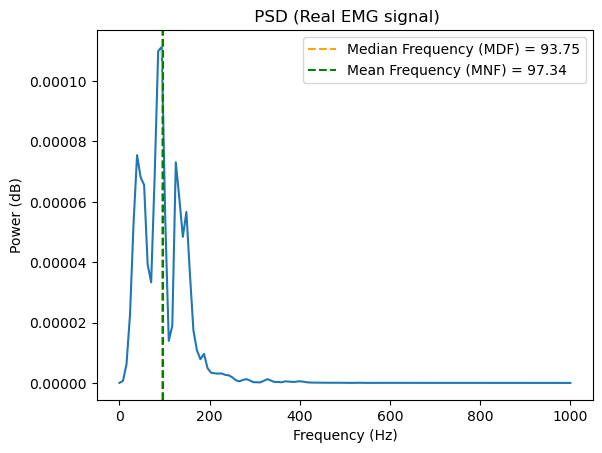

In [15]:
psd_welch, f_welch, MNF = superlet.compute_psd_welch(emg, Fs, plot=True, muscle='Real EMG signal')
MNF_1 = [MNF]

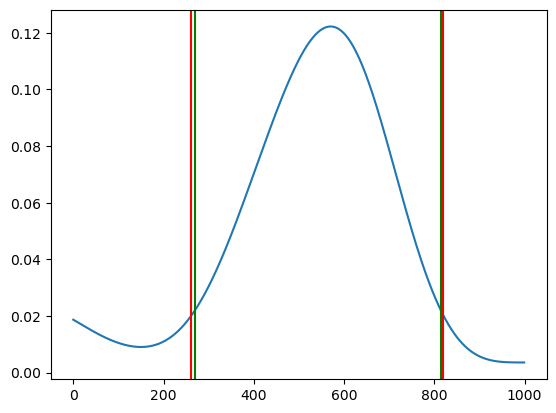

In [21]:
emg_rectified = abs(emg)
w1 = (2 / Fs) * 5
b, a = signal_scipy.butter(3, w1, btype='lowpass')
emg_envelope = signal_scipy.filtfilt(b, a, emg_rectified)

plt.plot(emg_envelope)

threshold = 0.00002 * 1000
threshold_2  = 0.18*np.max(emg_envelope)
start = emg_envelope > threshold
end = emg_envelope < threshold
start_2 = emg_envelope > threshold_2
end_2 = emg_envelope < threshold_2

start_idx = np.where(start == True)[0][0]
end_idx = np.where(start == True)[0][-1]
start_idx_2 = np.where(start_2 == True)[0][0]
end_idx_2 = np.where(start_2 == True)[0][-1]

plt.axvline(start_idx, color = 'red')
plt.axvline(end_idx, color = 'red')
plt.axvline(start_idx_2, color = 'green')
plt.axvline(end_idx_2, color = 'green')

real_t_onset = start_idx / Fs
real_t_offset = end_idx / Fs
burst_duration = real_t_offset - real_t_onset


In [22]:
start_idx

261

In [23]:
end_idx

820

### Definición del vector de frecuencia

In [24]:
frange = np.linspace(10,500,int(Fs/2)) # Número de puntos del vector frecuencia
freq_min = frange[0]  # Minimum freq
freq_max = frange[-1]  # Frecuencia máxima
num_freqs = len(frange)  # Resolución del rango de frecuencias

In [25]:
y = emg

In [26]:
save = True
save_figures = True

if save:
    new_folder_path = os.path.join(folder_out, str(round(MNF_1[0], 2)) + ' Hz')
    os.makedirs(new_folder_path, exist_ok=True)

In [29]:
norm = 'freq_sqrt'
plot_scalogram = True


SST params: step=10, baseCycle=17
SLT params: baseCycle=8, o_min=1, o_max=118
CWT params: step=11, baseCycle=3
Our CWT params: cycles=39
    SST time: 8.454s
    CWT time: 1.120s
    SLT time: 120.857s
    Our CWT: 0.147s


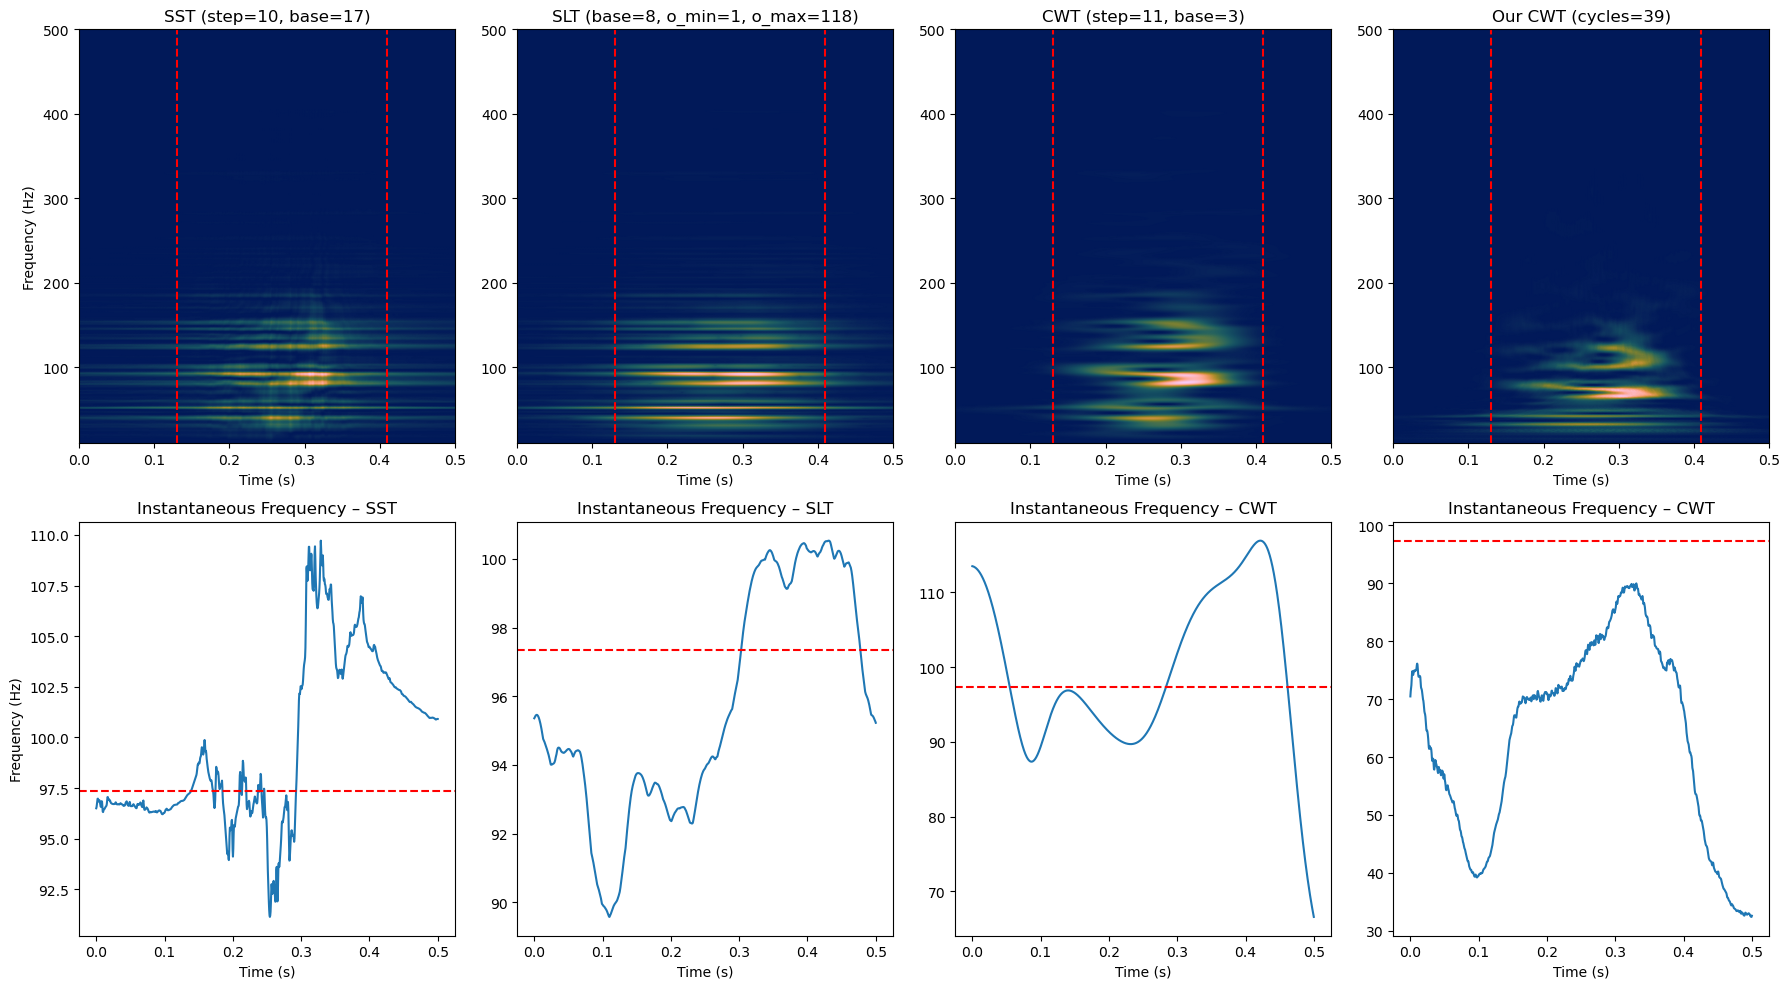

Reference MNF = 97.34442313932318 Hz
    Estimated MNF (SST) = 100.20052442183149 Hz
    Estimated MNF (SLT) = 95.94803507208107 Hz
    Estimated MNF (CWT) = 100.12562290107302 Hz
    Estimated MNF (Our CWT) = 75.56020687561777 Hz
Reference onset = 0.1305 s, reference offset = 0.41 s
    Estimated onset (SST) = 0.17343893893893894 s, offset = 0.39073273273273273 s
    Estimated onset (SLT) = 0.13054954954954953 s, offset = 0.4276601601601602 s
    Estimated onset (CWT) = 0.2037127127127127 s, offset = 0.3694854854854855 s
    Estimated onset (CWT) = 0.21403603603603602 s, offset = 0.36964214214214214 s

SST params: step=10, baseCycle=17
SLT params: baseCycle=17, o_min=1, o_max=142
CWT params: step=10, baseCycle=8
Our CWT params: cycles=43
    SST time: 7.084s
    CWT time: 3.285s
    SLT time: 131.976s
    Our CWT: 0.130s


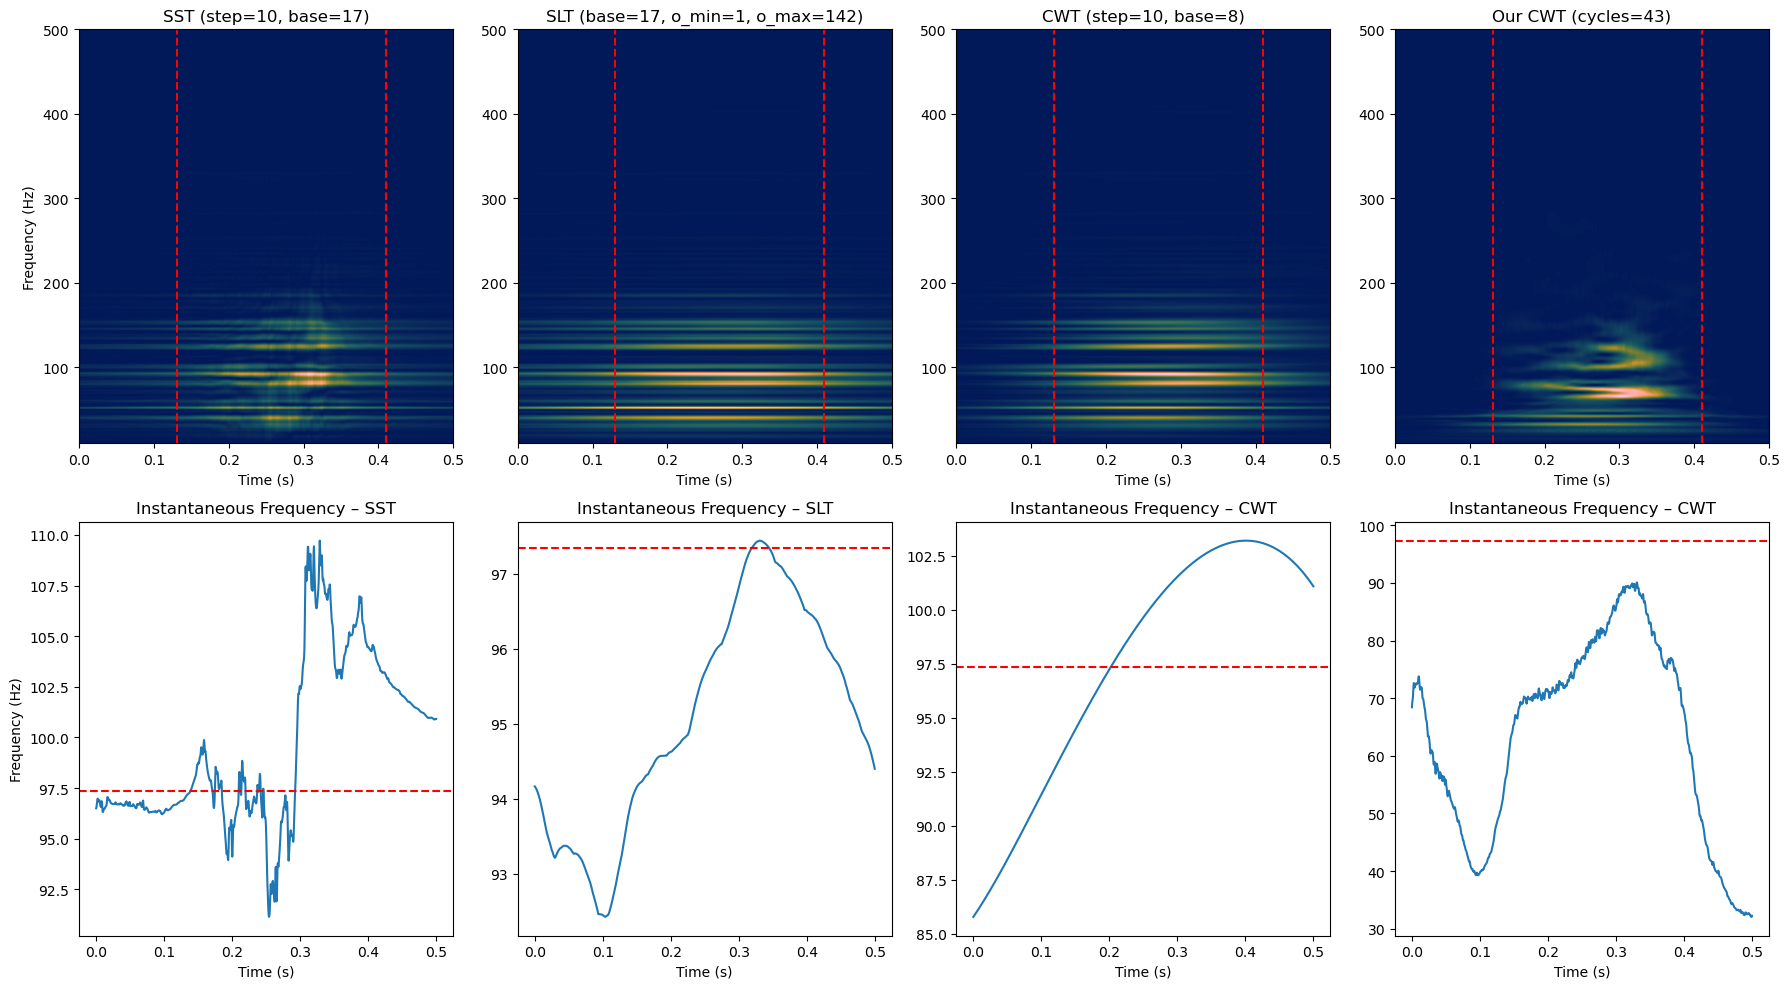

Reference MNF = 97.34442313932318 Hz
    Estimated MNF (SST) = 100.20052442183149 Hz
    Estimated MNF (SLT) = 95.83017824529684 Hz
    Estimated MNF (CWT) = 99.72206231584637 Hz
    Estimated MNF (Our CWT) = 75.74672336415905 Hz
Reference onset = 0.1305 s, reference offset = 0.41 s
    Estimated onset (SST) = 0.17343893893893894 s, offset = 0.39073273273273273 s
    Estimated onset (SLT) = 0.0242992992992993 s, offset = 0.4955945945945946 s
    Estimated onset (CWT) = 0.12361461461461462 s, offset = 0.4461186186186186 s
    Estimated onset (CWT) = 0.21097347347347345 s, offset = 0.3701986986986987 s

SST params: step=67, baseCycle=3
SLT params: baseCycle=8, o_min=4, o_max=103
CWT params: step=79, baseCycle=4
Our CWT params: cycles=1
    SST time: 0.284s
    CWT time: 0.317s
    SLT time: 91.248s
    Our CWT: 0.125s


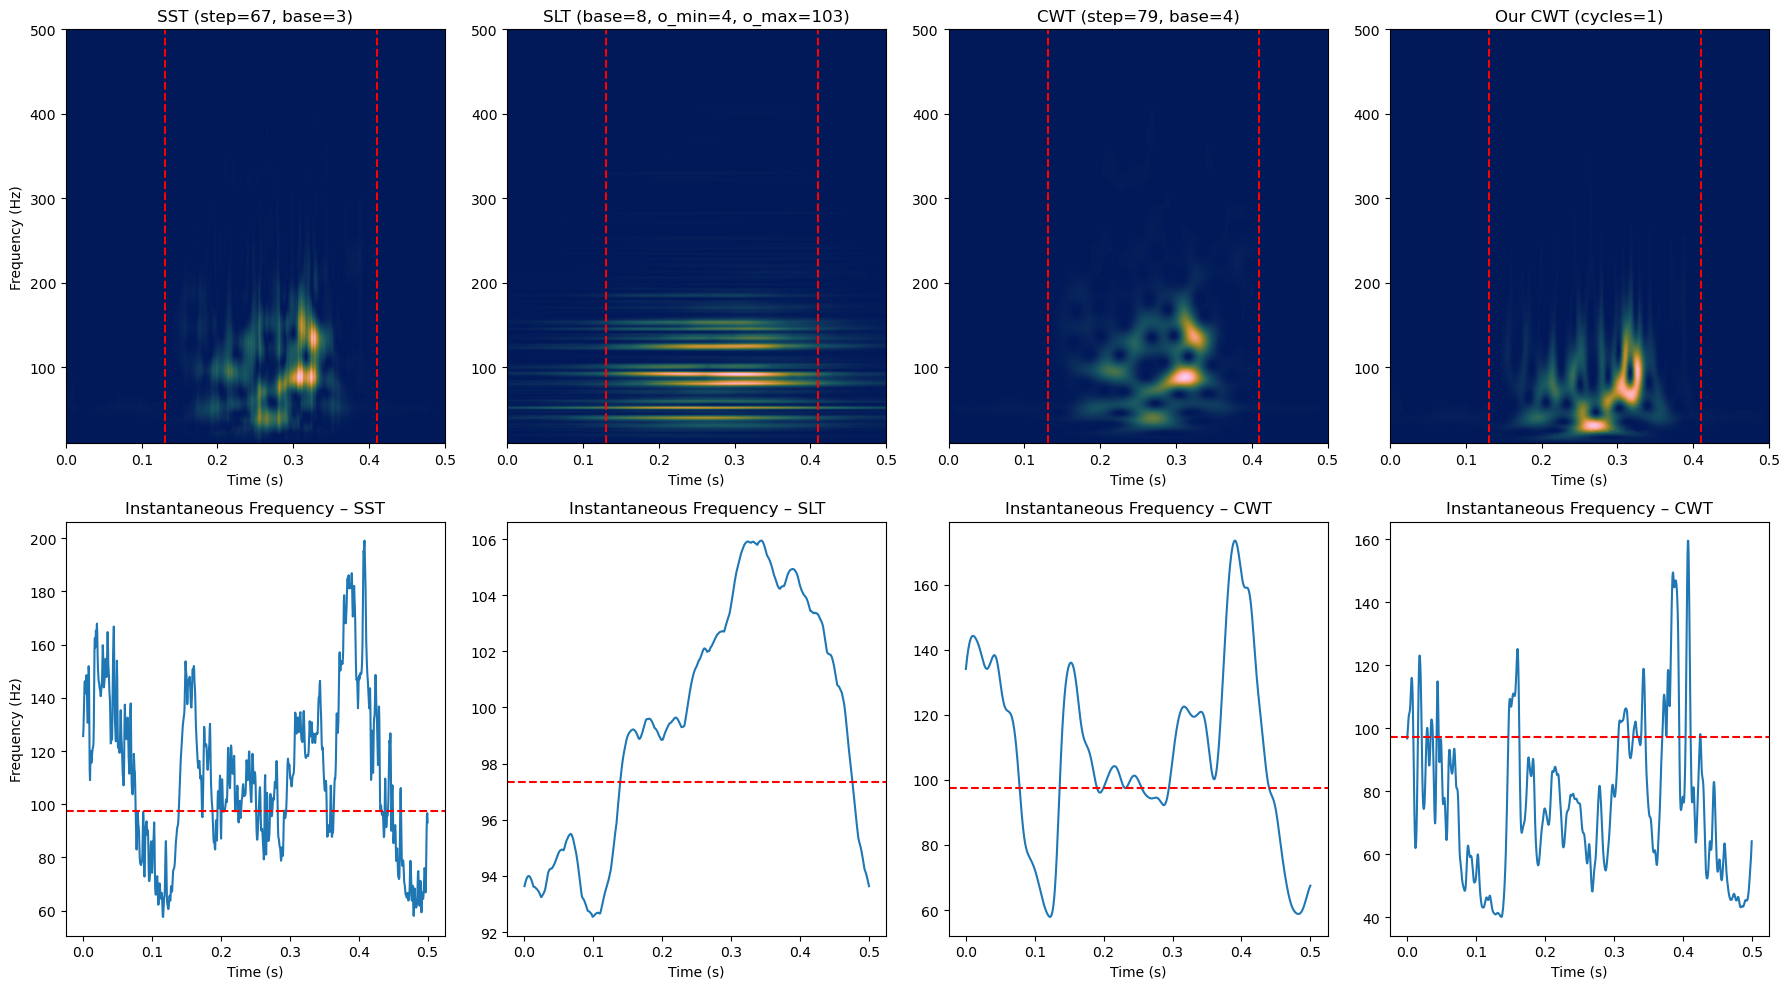

Reference MNF = 97.34442313932318 Hz
    Estimated MNF (SST) = 118.44355012643979 Hz
    Estimated MNF (SLT) = 102.0534716417659 Hz
    Estimated MNF (CWT) = 114.7917927711935 Hz
    Estimated MNF (Our CWT) = 83.5485842489266 Hz
Reference onset = 0.1305 s, reference offset = 0.41 s
    Estimated onset (SST) = 0.22129429429429429 s, offset = 0.35263113113113115 s
    Estimated onset (SLT) = 0.13514164164164164 s, offset = 0.4246051051051051 s
    Estimated onset (CWT) = 0.21813113113113114 s, offset = 0.35851901901901906 s
    Estimated onset (CWT) = 0.21985085085085082 s, offset = 0.3604854854854855 s
Cálculo finalizado.


In [31]:
import time
# Se asume que matplotlib.pyplot y cmasher están importados en el entorno.
# import matplotlib.pyplot as plt
# import cmasher as cmc 

# =========================================================================
# === DEFINICIÓN DE PARÁMETROS ÓPTIMOS ===

# 1. Parámetros óptimos para Singular Superlet Transform (SST): (step, base)
params_sst = [[10,10,67], [17,17,3]] 

# 2. Parámetros óptimos para Superlet Convencional (SLT): (base, o_min, o_max)
# Utilizamos una lista triple para base, o_min y o_max.
# (Ejemplo: 3 combinaciones optimizadas)
params_slt = [[8,17,8], [1,1,4], [118,142,103]] 

# 3. Parámetros óptimos para CWT (Morlet Adaptativa/Similar): (step, base)
# (Ejemplo: 3 combinaciones optimizadas)
params_cwt_opt = [[11,10,79], [3,8,4]] 

params_our_cwt = [39,43,1]
# =========================================================================


# Inicialización de listas de métricas 
mae_sst_f, std_sst_f = [], []
mae_slt_f, std_slt_f = [], []
mae_cwt_f, std_cwt_f = [], []
mae_our_cwt_f, std_our_cwt_f = [], []

mae_sst_t, std_sst_t = [], []
mae_slt_t, std_slt_t = [], []
mae_cwt_t, std_cwt_t = [], []
mae_our_cwt_t, std_our_cwt_t = [], []

params_list = []
smooth_sigma = 20

# Iteración sobre los parámetros óptimos para cada método
# sst_params será (step_sst, base_sst)
# slt_params será (base_slt, o_min_slt, o_max_slt)
# cwt_params será (step_cwt, base_cwt)
for (sst_params, slt_params, cwt_params, our_cwt_params) in zip(zip(*params_sst), zip(*params_slt), zip(*params_cwt_opt), params_our_cwt):
    # Parámetros SST
    step_sst, base_sst = sst_params
    # Parámetros SLT (NUEVA ESTRUCTURA)
    base_slt, o_min_slt, o_max_slt = slt_params
    # Parámetros CWT
    step_cwt, base_cwt = cwt_params
    
    cycles_our_cwt = our_cwt_params
    
    print(f"\n==============================")
    print(f"SST params: step={step_sst}, baseCycle={base_sst}")
    print(f"SLT params: baseCycle={base_slt}, o_min={o_min_slt}, o_max={o_max_slt}")
    print(f"CWT params: step={step_cwt}, baseCycle={base_cwt}")
    print(f"Our CWT params: cycles={cycles_our_cwt}")
       
    # --- 1. Cálculo SST (Singular Superlet) ---
    start_time = time.time()
    # SST devuelve o_min y o_max, calculados internamente usando 'step'
    sstRez, o_min_sst, o_max_sst = sst.sst(y, frange, Fs, base_sst, norm, step_sst)
    sst_time = time.time() - start_time
    print(f"    SST time: {sst_time:.3f}s")

    # --- 2. Cálculo CWT (Morlet Adaptativa) ---
    start_time_cwt = time.time()
    # Utiliza step_cwt y base_cwt
    cwtRez = cwt.cwt(y, frange, Fs, base_cwt, norm, step_cwt) 
    cwt_time = time.time() - start_time_cwt
    print(f"    CWT time: {cwt_time:.3f}s")

    # --- 3. Cálculo SLT (Superlet Convencional) ---
    start_time_slt = time.time()
    # Utiliza base_slt, o_min_slt, y o_max_slt
    wv, sltRez = superlet.adaptive_superlet_transform(
        y, frange, sampling_freq=Fs, base_cycle=base_slt, min_order=o_min_slt, max_order=o_max_slt, mode="mul"
    )
    slt_time = time.time() - start_time_slt
    sltRez_scalogram = np.array(jnp.abs(sltRez)**2)
    print(f"    SLT time: {slt_time:.3f}s")
    
    start_time_our_cwt = time.time()
    wavelet = f'cmor{cycles_our_cwt}-1.0'
    cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(y,wavelet,frange,Fs)
    cwt_scalogram = np.array(jnp.abs(cwtmatr)**2)
    our_cwt_time = time.time() - start_time_our_cwt
    print(f"    Our CWT: {our_cwt_time:.3f}s")
    
    burst_times = np.array([[real_t_onset, real_t_offset]])
    
    eps = 1e-12
    # Calcular MAE en frecuencia
    instant_freq_sst = np.sum(sstRez * frange[:, None], axis=0) / (np.sum(sstRez, axis=0) + eps)
    instant_freq_slt = np.sum(sltRez_scalogram * frange[:, None], axis=0) / (np.sum(sltRez_scalogram, axis=0) + eps)
    instant_freq_cwt = np.sum(cwtRez * frange[:, None], axis=0) / (np.sum(cwtRez, axis=0) + eps)
    instant_freq_our_cwt = np.sum(cwt_scalogram * frange[:, None], axis=0) / (np.sum(cwt_scalogram, axis=0) + eps)

    if plot_scalogram:
        fig, axs = plt.subplots(2, 4, figsize=(18, 10))
        
        # SST scalogram
        for start, end in burst_times:
            axs[0, 0].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
        pcm0 = axs[0, 0].pcolormesh(t, frange, sstRez, shading='gouraud', cmap=cmc.batlow)
        axs[0, 0].set_title(f"SST (step={step_sst}, base={base_sst})")
        axs[0, 0].set_xlabel("Time (s)")
        axs[0, 0].set_ylabel("Frequency (Hz)")

        # SLT scalogram
        for start, end in burst_times:
            axs[0, 1].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
        pcm1 = axs[0, 1].pcolormesh(t, frange, sltRez_scalogram, shading='gouraud', cmap=cmc.batlow)
        axs[0, 1].set_title(f"SLT (base={base_slt}, o_min={o_min_slt}, o_max={o_max_slt})") # Título actualizado
        axs[0, 1].set_xlabel("Time (s)")

        # CWT scalogram
        for start, end in burst_times:
            axs[0, 2].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
        pcm2 = axs[0, 2].pcolormesh(t, frange, cwtRez, shading='gouraud', cmap=cmc.batlow)
        axs[0, 2].set_title(f"CWT (step={step_cwt}, base={base_cwt})") 
        axs[0, 2].set_xlabel("Time (s)")
        
        for start, end in burst_times:
            axs[0, 3].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
        pcm2 = axs[0, 3].pcolormesh(t, frange, cwt_scalogram, shading='gouraud', cmap=cmc.batlow)
        axs[0, 3].set_title(f"Our CWT (cycles={cycles_our_cwt})") 
        axs[0, 3].set_xlabel("Time (s)")

        # Frecuencias Instantáneas
        axs[1, 0].plot(t, instant_freq_sst)
        axs[1, 0].axhline(MNF_1[0], color='r', linestyle='--')
        axs[1, 0].set_title("Instantaneous Frequency – SST")
        axs[1, 0].set_xlabel("Time (s)")
        axs[1, 0].set_ylabel("Frequency (Hz)")

        axs[1, 1].plot(t, instant_freq_slt)
        axs[1, 1].axhline(MNF_1[0], color='r', linestyle='--')
        axs[1, 1].set_title("Instantaneous Frequency – SLT")
        axs[1, 1].set_xlabel("Time (s)")

        axs[1, 2].plot(t, instant_freq_cwt)
        axs[1, 2].axhline(MNF_1[0], color='r', linestyle='--')
        axs[1, 2].set_title("Instantaneous Frequency – CWT")
        axs[1, 2].set_xlabel("Time (s)")
        
        axs[1, 3].plot(t, instant_freq_our_cwt)
        axs[1, 3].axhline(MNF_1[0], color='r', linestyle='--')
        axs[1, 3].set_title("Instantaneous Frequency – CWT")
        axs[1, 3].set_xlabel("Time (s)")
        
        plt.tight_layout()
        plt.show()

    instant_freq_burst_sst = instant_freq_sst[start_idx:end_idx]
    instant_freq_burst_slt = instant_freq_slt[start_idx:end_idx]
    instant_freq_burst_cwt = instant_freq_cwt[start_idx:end_idx]
    instant_freq_burst_our_cwt = instant_freq_our_cwt[start_idx:end_idx]
    print(f'Reference MNF = {MNF_1[0]} Hz')
    
    # MAE Frecuencia SST
    print(f'    Estimated MNF (SST) = {np.mean(instant_freq_burst_sst)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_freq_burst_sst, MNF_1[0])
    mae_sst_f.append(mae_f)
    std_sst_f.append(std_f)

    # MAE Frecuencia SLT
    print(f'    Estimated MNF (SLT) = {np.mean(instant_freq_burst_slt)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_freq_burst_slt, MNF_1[0])
    mae_slt_f.append(mae_f)
    std_slt_f.append(std_f)

    # MAE Frecuencia CWT
    print(f'    Estimated MNF (CWT) = {np.mean(instant_freq_burst_cwt)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_freq_burst_cwt, MNF_1[0])
    mae_cwt_f.append(mae_f)
    std_cwt_f.append(std_f)

    print(f'    Estimated MNF (Our CWT) = {np.mean(instant_freq_burst_our_cwt)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_freq_burst_our_cwt, MNF_1[0])
    mae_our_cwt_f.append(mae_f)
    std_our_cwt_f.append(std_f) 
    
    energia_temporal_sst = sstRez
    energia_temporal_slt = sltRez_scalogram
    energia_temporal_cwt = cwtRez
    energia_temporal_our_cwt = cwt_scalogram
    
    first_indices_sst = []
    last_indices_sst = []
    first_indices_cwt = []
    last_indices_cwt = []
    first_indices_our_cwt = []
    last_indices_our_cwt = []
    first_indices_slt = []
    last_indices_slt = []
    
    for row in energia_temporal_sst:
        first_index, last_index = superlet.find_plateau_region(row, real_t_onset, burst_duration, t, Fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
        first_indices_sst.append(first_index)
        last_indices_sst.append(last_index)
        
    t_onset_sst = t[first_indices_sst]
    t_offset_sst = t[last_indices_sst]
    
    for row in energia_temporal_cwt:
        first_index, last_index = superlet.find_plateau_region(row, real_t_onset, burst_duration, t, Fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
        first_indices_cwt.append(first_index)
        last_indices_cwt.append(last_index)
        
    t_onset_cwt = t[first_indices_cwt]
    t_offset_cwt = t[last_indices_cwt]
    
    for row in energia_temporal_our_cwt:
        first_index, last_index = superlet.find_plateau_region(row, real_t_onset, burst_duration, t, Fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
        first_indices_our_cwt.append(first_index)
        last_indices_our_cwt.append(last_index)
        
    t_onset_our_cwt = t[first_indices_our_cwt]
    t_offset_our_cwt = t[last_indices_our_cwt]
    
    for row in energia_temporal_slt:
        first_index, last_index = superlet.find_plateau_region(row, real_t_onset, burst_duration, t, Fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
        first_indices_slt.append(first_index)
        last_indices_slt.append(last_index)
        
    t_onset_slt = t[first_indices_slt]
    t_offset_slt = t[last_indices_slt]
    

    print(f'Reference onset = {real_t_onset} s, reference offset = {real_t_offset} s')
    
    # MAE Tiempo SST
    print(f'    Estimated onset (SST) = {np.mean(t_onset_sst)} s, offset = {np.mean(t_offset_sst)} s')
    mae_t, std_t = superlet.calculate_mae((t_onset_sst, t_offset_sst), (real_t_onset, real_t_offset))
    mae_sst_t.append(mae_t)
    std_sst_t.append(std_t)

    # MAE Tiempo SLT
    print(f'    Estimated onset (SLT) = {np.mean(t_onset_slt)} s, offset = {np.mean(t_offset_slt)} s')
    mae_t, std_t = superlet.calculate_mae((t_onset_slt, t_offset_slt), (real_t_onset, real_t_offset))
    mae_slt_t.append(mae_t)
    std_slt_t.append(std_t)

    # MAE Tiempo CWT
    print(f'    Estimated onset (CWT) = {np.mean(t_onset_cwt)} s, offset = {np.mean(t_offset_cwt)} s')
    mae_t, std_t = superlet.calculate_mae((t_onset_cwt, t_offset_cwt), (real_t_onset, real_t_offset))
    mae_cwt_t.append(mae_t)
    std_cwt_t.append(std_t)
    
    # MAE Tiempo CWT
    print(f'    Estimated onset (CWT) = {np.mean(t_onset_our_cwt)} s, offset = {np.mean(t_offset_our_cwt)} s')
    mae_t, std_t = superlet.calculate_mae((t_onset_our_cwt, t_offset_our_cwt), (real_t_onset, real_t_offset))
    mae_our_cwt_t.append(mae_t)
    std_our_cwt_t.append(std_t)

    params_list.append({
        'SST': (step_sst, base_sst),
        'SLT': (base_slt, o_min_slt, o_max_slt),
        'CWT': (step_cwt, base_cwt),
        'Our CWT': (cycles_our_cwt)
    })


print("Cálculo finalizado.")

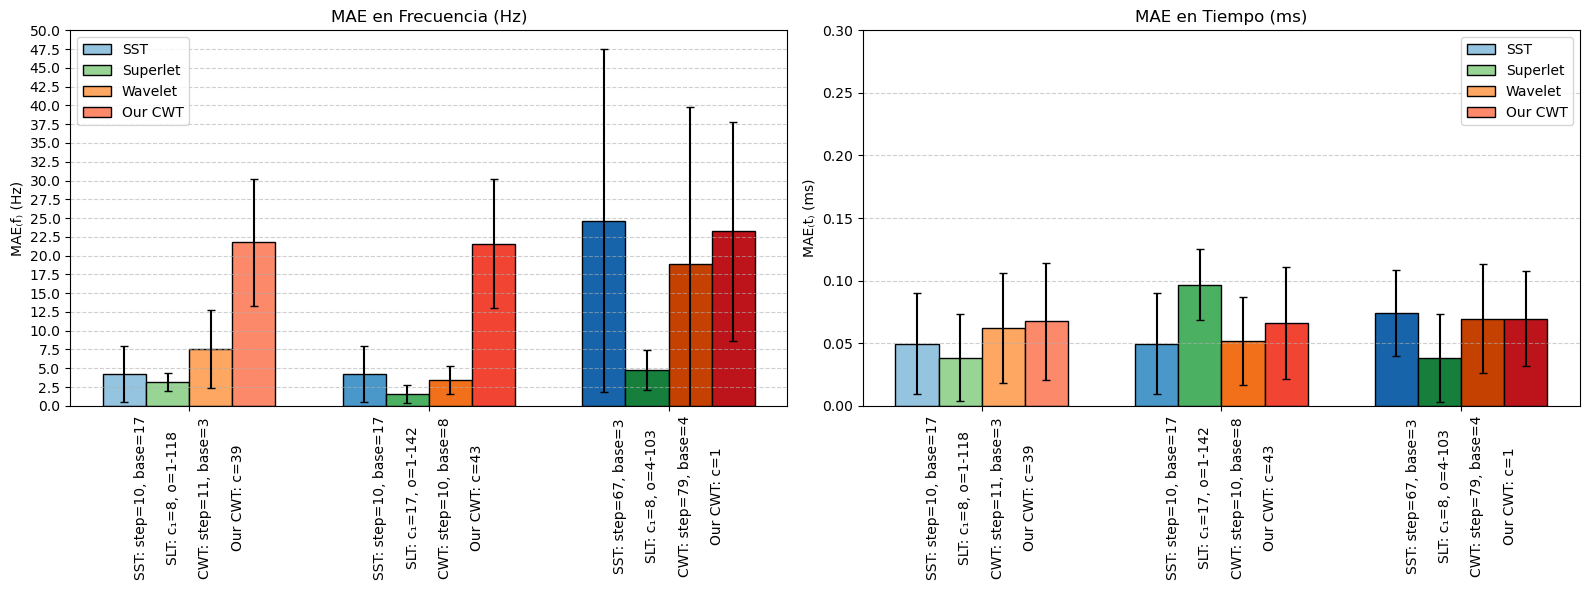

In [32]:
# ====================== CONFIGURACIÓN ======================

num_params = len(params_list)
x = np.arange(num_params)
bar_width = 0.18

# Desplazamiento horizontal de cada método
offsets = {
    "SST":     -1.5 * bar_width,
    "Superlet": -0.5 * bar_width,
    "Wavelet":   0.5 * bar_width,
    "Our CWT":   1.5 * bar_width
}

# Colores base para cada método
colores_base = {
    "SST":     plt.colormaps["Blues"],
    "Superlet": plt.colormaps["Greens"],
    "Wavelet":  plt.colormaps["Oranges"],
    "Our CWT":  plt.colormaps["Reds"]
}

# Tonos diferentes para cada parámetro (0.4 → 0.8)
tonos = np.linspace(0.4, 0.8, num_params)


# ====================== ETIQUETAS ======================

labels = []
for i in range(num_params):

    step_sst, base_sst = params_sst[0][i], params_sst[1][i]
    c1_slt, omin_slt, omax_slt = params_slt[0][i], params_slt[1][i], params_slt[2][i]
    step_cwt, base_cwt = params_cwt_opt[0][i], params_cwt_opt[1][i]
    c_our = params_our_cwt[i]

    label = (
        f"SST: step={step_sst}, base={base_sst}\n\n"
        f"SLT: c₁={c1_slt}, o={omin_slt}-{omax_slt}\n\n"
        f"CWT: step={step_cwt}, base={base_cwt}\n\n"
        f"Our CWT: c={c_our}"
    )
    labels.append(label)


# ====================== FIGURA CON DOS SUBPLOTS ======================

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Función para dibujar barras
def plot_bars(ax, nombre, maes, stds):
    ax.bar(
        x + offsets[nombre],
        maes,
        width=bar_width,
        color=[colores_base[nombre](tonos[i]) for i in range(num_params)],
        edgecolor="black",
        label=nombre
    )
    ax.errorbar(
        x + offsets[nombre],
        maes,
        yerr=stds,
        fmt="none",
        ecolor="black",
        capsize=3
    )


# ====================== SUBPLOT 1: MAE FRECUENCIA ======================

ax = axes[0]
plot_bars(ax, "SST",      mae_sst_f,      std_sst_f)
plot_bars(ax, "Superlet", mae_slt_f,      std_slt_f)
plot_bars(ax, "Wavelet",  mae_cwt_f,      std_cwt_f)
plot_bars(ax, "Our CWT",  mae_our_cwt_f,  std_our_cwt_f)

ax.set_title("MAE en Frecuencia (Hz)")
ax.set_ylabel("MAE₍f₎ (Hz)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.set_ylim(0, 50) 
ax.set_yticks(np.arange(0, 52.5, 2.5))
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend()


# ====================== SUBPLOT 2: MAE TIEMPO ======================

ax = axes[1]
plot_bars(ax, "SST",      mae_sst_t,      std_sst_t)
plot_bars(ax, "Superlet", mae_slt_t,      std_slt_t)
plot_bars(ax, "Wavelet",  mae_cwt_t,      std_cwt_t)
plot_bars(ax, "Our CWT",  mae_our_cwt_t,  std_our_cwt_t)

ax.set_title("MAE en Tiempo (ms)")
ax.set_ylabel("MAE₍t₎ (ms)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.set_ylim(0, 0.3) 
ax.set_yticks(np.arange(0, 0.35, 0.05))
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend()


plt.tight_layout()
plt.show()

# COEFFICIENT OF VARIATION

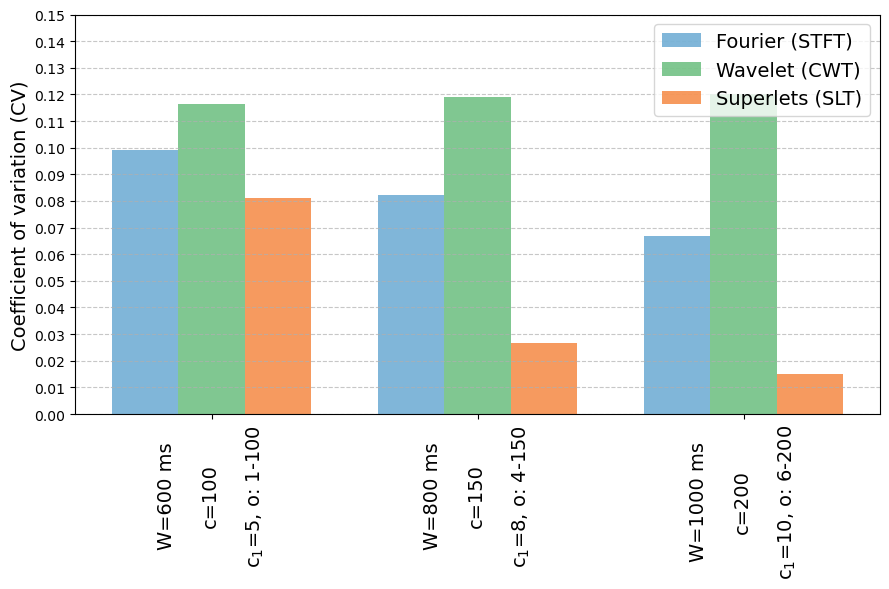

In [42]:
# Número de condiciones
num_conditions = len(cv_wavelet_f)
x = np.arange(num_conditions)
bar_width = 0.25

plt.figure(figsize=(9, 6))

# Solo los valores de CV, sin std
plt.bar(x - bar_width, cv_stft_f, width=bar_width, label='Fourier (STFT)', color=colores_base["STFT"](tonalidades[1]), alpha=0.7)
plt.bar(x, cv_wavelet_f, width=bar_width, label='Wavelet (CWT)', color=colores_base["Wavelet"](tonalidades[1]), alpha=0.7)
plt.bar(x + bar_width, cv_superlet_f, width=bar_width, label='Superlets (SLT)', color=colores_base["Superlet"](tonalidades[1]), alpha=0.7)

# Etiquetas
labels = [
    f"W={p_stft} ms\n\nc={p_w}\n\nc$_1$={p_s[0]}, o: {p_s[1]}-{p_s[2]}"
    for p_w, p_s, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

plt.xticks(x, labels, rotation=90, ha='center', fontsize=fontsize_labels)
plt.yticks(np.arange(0, 0.16, 0.01))
plt.ylabel('Coefficient of variation (CV)', fontsize=fontsize_labels)
# plt.title('Coeficiente de variación de frecuencia instantánea (Real EMG signal)', fontsize=fontsize_title)
plt.ylim(0, 0.15)
plt.legend(fontsize=fontsize_legend, loc='upper right')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

if save_figures:
    plt.savefig(os.path.join(new_folder_path,"coefficient_variation_real.png"), dpi=300, bbox_inches="tight")
    
plt.show()

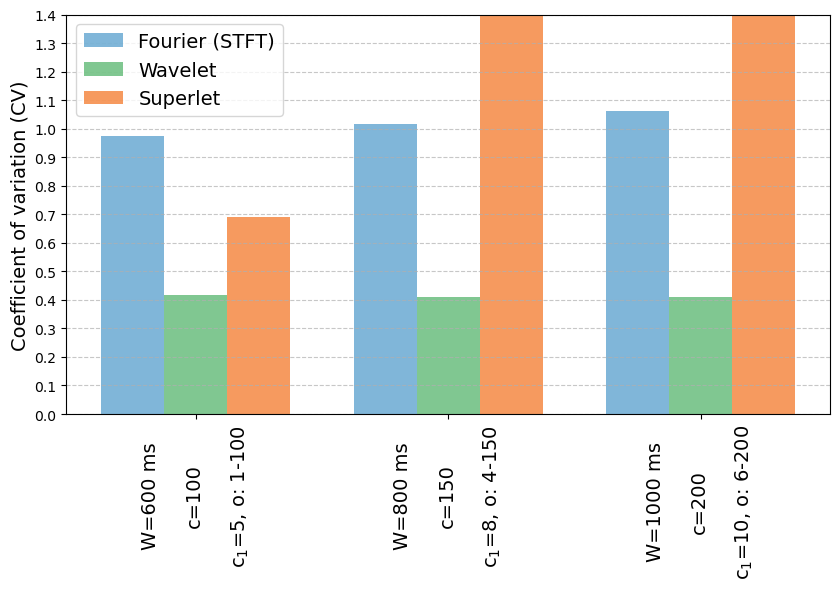

In [43]:
# Número de condiciones
num_conditions = len(cv_wavelet_f)
x = np.arange(num_conditions)
bar_width = 0.25

plt.figure(figsize=(8.5, 6))

# Solo los valores de CV, sin std
plt.bar(x - bar_width, cv_stft_t, width=bar_width, label='Fourier (STFT)', color=colores_base["STFT"](tonalidades[1]), alpha=0.7)
plt.bar(x, cv_wavelet_t, width=bar_width, label='Wavelet', color=colores_base["Wavelet"](tonalidades[1]), alpha=0.7)
plt.bar(x + bar_width, cv_superlet_t, width=bar_width, label='Superlet', color=colores_base["Superlet"](tonalidades[1]), alpha=0.7)

# Etiquetas
labels = [
    f"W={p_stft} ms\n\nc={p_w}\n\nc$_1$={p_s[0]}, o: {p_s[1]}-{p_s[2]}"
    for p_w, p_s, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

plt.xticks(x, labels, rotation=90, ha='center', fontsize=fontsize_labels)
plt.yticks(np.arange(0, 1.5, 0.1))
plt.ylabel('Coefficient of variation (CV)', fontsize=fontsize_labels)
# plt.title('Coeficiente de variación del tiempo (Real EMG signal)', fontsize=18)
plt.ylim(0, 1.4)
plt.legend(fontsize=fontsize_legend)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

if save_figures:
    plt.savefig(os.path.join(new_folder_path,"coefficient_variation_time_real.png"), dpi=300, bbox_inches="tight")
    
plt.show()

# Only first time !!!!

In [44]:
MAES_f = {
    'stft': [],
    'wavelet': [],
    'superlet': [],
    'std_stft': [],
    'std_wavelet': [],
    'std_superlet': []
}

In [45]:
MAES_f['wavelet'].append(mae_wavelet_f)
MAES_f['stft'].append(mae_stft_f)
MAES_f['superlet'].append(mae_superlet_f)
MAES_f['std_wavelet'].append(std_wavelet_f)
MAES_f['std_stft'].append(std_stft_f)
MAES_f['std_superlet'].append(std_superlet_f)

In [46]:
MAES_f

{'stft': [[8.493553433992874, 7.207042567393985, 5.928304068968278]],
 'wavelet': [[9.320469477394633, 9.577714356046108, 9.75886523573635]],
 'superlet': [[7.555552682128446, 2.770536473818185, 1.5655352466807257]],
 'std_stft': [[4.759293662704667, 3.4355345369432153, 2.748203914497318]],
 'std_wavelet': [[6.32306909037063, 6.498909608119951, 6.618850312641356]],
 'std_superlet': [[3.501082439927184, 1.367880229190701, 0.917967384353732]]}

In [47]:
MAES_t = {
    'stft': [],
    'wavelet': [],
    'superlet': [],
    'std_stft': [],
    'std_wavelet': [],
    'std_superlet': []
}

In [48]:
MAES_t['wavelet'].append(mae_wavelet_t)
MAES_t['stft'].append(mae_stft_t)
MAES_t['superlet'].append(mae_superlet_t)
MAES_t['std_wavelet'].append(std_wavelet_t)
MAES_t['std_stft'].append(std_stft_t)
MAES_t['std_superlet'].append(std_superlet_t)

In [49]:
MAES_t

{'stft': [[0.06126923076923077, 0.06453371628371628, 0.0701593406593407]],
 'wavelet': [[0.03198175375375375, 0.031609905905905906, 0.03154821371371371]],
 'superlet': [[0.04517671421421422, 0.1019008528528529, 0.11019069069069073]],
 'std_stft': [[0.04509499566109325,
   0.043508651258584004,
   0.041156566574395426]],
 'std_wavelet': [[0.027464772635708134,
   0.026795564813910593,
   0.02660768992685072]],
 'std_superlet': [[0.03757321416728135,
   0.02549908033281272,
   0.02028529091329099]]}

# WE REPEAT EVERYTHING WITH DIFFERENT SNR

In [50]:
if os.path.exists(filename):
    burst_signal = np.load(filename) + base_signal
else:
    #burst_signal = np.random.normal(0, 0.08, len(t))
    burst_signal = np.array([0.00001] * len(t))
    burst_signal[int(burst_start * fs):int(burst_start * fs + len(burst))] = burst
    #np.save('/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/signal_burst_1.npy', burst_signal)

plt.plot(noise)
plt.figure()
plt.plot(burst_signal)

NameError: name 'filename' is not defined

In [ ]:
plt.plot(burst_signal)
plt.plot(base_signal)

In [ ]:
SNR = 15
# if 'SNR' not in globals():
#     SNR = "Inf"
signal_2 = burst_signal
# signal_2, xn = superlet.add_noise(burst_signal, SNR, fs, plot = True)
# #signal_2 = superlet.add_wgn_to_sig(burst_signal, noise, SNR)
# snr_real = calcular_snr(signal_2, xn)
np.save('/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/signal_2.npy', signal_2)

In [ ]:
psd_welch, f_welch, MNF = superlet.compute_psd_welch(signal_2, fs, plot=True, muscle='Simulated EMG signal with burst')
if save:
    plt.savefig(os.path.join(new_folder_path,"psd_snr_15.png"), dpi=300, bbox_inches="tight")

In [ ]:
plt.plot(signal_1)
plt.plot(signal_2)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 2), dpi=300)
ax.set_xlabel("Time (s)")
ax.plot(jnp.linspace(0, len(signal_2) / fs, len(signal_2)), signal_2)
print(f"Reference mean frequency: {MNF_1[0]} Hz")
plt.plot(t, signal_2)
if save:
    plt.savefig(os.path.join(new_folder_path,"signal_snr_15.png"), dpi=300, bbox_inches="tight")

# WAVELET PARAMETERS = 3, 16, 33, 55, 60 115 cycles

In [ ]:
plot_scalogram = True
plot_response = True

In [ ]:
if plot_scalogram:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_imnf:
    fig_2, ax_2 = plt.subplots(ncols=len(params_wavelet), figsize=(18, 5), dpi=300)
if plot_response:
    fig_3, (ax_3_1, ax_3_2) = plt.subplots(1, 2, figsize=(18, 5))  

mae_wavelet_f = []
std_wavelet_f = []

mae_wavelet_t = []
std_wavelet_t = []

cv_wavelet = []

total_time = []
total_freq = []

for i, c in enumerate(params_wavelet):
    wavelet = f'cmor{c}-1.0'
    
    cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(signal_2,wavelet,freqs,fs)
    cwtmatr = np.abs(cwtmatr[:,:])
    
    scalogram_2 = np.array(jnp.abs(cwtmatr)**2)
    
    if plot_scalogram:
        vmin = np.percentile(scalogram_2, 1)   # 5% percentil para evitar valores extremos bajos
        vmax = np.percentile(scalogram_2, 99) 
        
        f_max = 300
        mask = f <= f_max  # Seleccionamos solo las frecuencias menores o iguales a 300 Hz
        
        pcm = ax[i].pcolormesh(t,f, scalogram_2, shading='gouraud', cmap='viridis')
    
        # pcm = ax[i].pcolormesh(t, f[mask], scalogram_2[mask, :], shading='gouraud', cmap='jet', vmin=vmin, vmax=vmax)
        
        ax[i].set_title(f'c={c}')
        if i == 0:
            ax[i].set_ylabel('Frequency (Hz)')
        else:
            ax[i].set_ylabel('')  # Eliminar la etiqueta del eje Y en los demás subplots
    
        ax[i].set_xlabel('Time (s)')
        ax[i].set_ylim(f[0], f_max)
        
    instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
    
    energia_temporal = np.sum(scalogram_2, axis=0)
    
    first_index, last_index = superlet.find_plateau_region(energia_temporal, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, plot = True, contamination = contamination)
    
    t_onset = t[first_index]
    t_offset = t[last_index]
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_imnf:
        ax_2[i].plot(t, instant_freq)
    
        ax_2[i].set_xlabel("Time (s)")
        ax_2[i].set_ylabel("Frequency (Hz)")
        #ax_2[i].set_xlim(t[0], t[-1])
        plt.title("Instantaneous frequency")
        ax_2[i].grid(True)
    
    if plot_response:
        ax_3_1.plot(t, instant_freq, label=f"c={c}")
        ax_3_1.set_xlabel("Time (s)")
        ax_3_1.set_ylabel("Frequency (Hz)")
        ax_3_1.legend()
        ax_3_1.grid(True)
        ax_3_1.set_title("Instantaneous frequency")
        
        ax_3_2.plot(t, energia_temporal, label=f"c={c}")
        ax_3_2.set_xlabel("Time (s)")
        ax_3_2.set_ylabel("Energy (V²)")
        ax_3_2.legend()
        ax_3_2.grid(True)
        ax_3_2.set_title("Energy over time")
        
    #MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
    mae_wavelet_f.append(mae_f)
    std_wavelet_f.append(std_f)
    
    #MAE in time
    print(f'Estimated onset = {t_onset} s, offset = {t_offset} s')
    mae_t, std_t = superlet.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_wavelet_t.append(mae_t)
    std_wavelet_t.append(std_t)
    
    # Coefficient of variation
    cv = np.std(instant_mean_freq_burst) / np.mean(instant_mean_freq_burst)
    print(f'Coefficient of variation = {cv}')
    cv_wavelet.append(cv)
    
    # Visualization
    plt.figure(figsize=(8, 5))

    plt.subplot(2, 1, 1)
    plt.plot(t, instant_freq)
    #plt.plot(t, media_movil)
    plt.axvline(t_onset, color='green', linestyle='--', label='t_onset')
    plt.axvline(t_offset, color='red', linestyle='--', label='t_offset')
    plt.xlabel('Time (s)')
    plt.ylabel('Freq (Hz)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    
    time = np.arange(scalogram_2.shape[1]) / fs

    total_time.append(time)
    total_freq.append(freqs)
    
#res_wavelet = superlet.compute_avg_response_resolution(total_scalogram_wavelet, total_time, total_freq, params_wavelet)

if plot_scalogram:
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)
    
if save_figures:
    fig.savefig(os.path.join(new_folder_path,"scalogram_wavelet_15.png"), dpi=300, bbox_inches="tight")
    fig_3.savefig(os.path.join(new_folder_path,"response_wavelet_15.png"), dpi=300, bbox_inches="tight")

In [ ]:
mae_wavelet_f

In [ ]:
mae_wavelet_t

## PARÁMETROS SUPERLET: base_cycle, min_order, max_order = [3, 5, 1, 1, 1, 1], [1, 1, 5, 10, 20, 30], [30, 30, 40, 100, 100, 200]

In [ ]:
signal_2 = emg

In [ ]:
if plot_scalogram:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_imnf:
    fig_2, ax_2 = plt.subplots(ncols=len(params_wavelet), figsize=(18, 5), dpi=300)
if plot_response:
    fig_3, (ax_3_1, ax_3_2) = plt.subplots(1, 2, figsize=(18, 5))

mae_superlet_f = []
std_superlet_f = []

mae_superlet_t = []
std_superlet_t = []

cv_superlet = []

total_time = []
total_freq = []

for (i, (base_cycle, min_order, max_order)) in enumerate(zip(*params_superlet)):

    wv, scalogram = superlet.adaptive_superlet_transform(signal_2, freqs, sampling_freq=fs,
                                                         base_cycle=base_cycle, min_order=min_order,
                                                         max_order=max_order, mode="mul")
    
    if plot_scalogram:
        vmin = np.percentile(jnp.abs(scalogram) ** 2, 1)   # 5% percentil
        vmax = np.percentile(jnp.abs(scalogram) ** 2, 99)  # 95% percentil

        # Filtrar frecuencias hasta 300 Hz
        mask = freqs <= f_max  # Seleccionamos solo las frecuencias <= 300 Hz
        
        #im = ax[i].imshow(jnp.abs(scalogram[mask, :]) ** 2, aspect="auto", cmap="jet", interpolation="none", origin="lower", extent=[0, len(signal_1) / fs, freqs[0], f_max], vmin=vmin, vmax=vmax)
        
        im = ax[i].imshow(jnp.abs(scalogram) ** 2, aspect='auto', cmap="jet", interpolation="none", origin="lower",extent=[0, len(signal_1) / fs, freqs[0], freqs[-1]])
        ax[i].set_title(f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax[i].set_xlabel("Time (s)")
        if i == 0:
            ax[i].set_ylabel("Frequency (Hz)")
        else:
            ax[i].set_ylabel("")
        ax[i].set_ylim(freqs[0], f_max)
        ax[i].grid(False)  # Asegura que la grid esté desactivada

    scalogram_2 = np.abs(scalogram) ** 2
    
    instant_freq = np.sum(scalogram_2 * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
        
    energia_temporal = np.sum(scalogram_2, axis=0)
        
    first_index, last_index = superlet.find_plateau_region(energia_temporal, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma)
    
    t_onset = t[first_index]
    t_offset = t[last_index]
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_imnf:
        ax_2[i].plot(t, instant_freq)

        ax_2[i].set_xlabel("Time (s)")
        ax_2[i].set_ylabel("Frequency (Hz)")
        #ax_2[i].set_xlim(t[0], t[-1])
        plt.title("Instantaneous frequency")
        ax_2[i].grid(True)

    if plot_response:
        ax_3_1.plot(t, instant_freq, label=f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax_3_1.set_xlabel("Time (s)")
        ax_3_1.set_ylabel("Frequency (Hz)")
        ax_3_1.legend()
        ax_3_1.grid(True)
        ax_3_1.set_title("Instantaneous frequency")
        
        ax_3_2.plot(t, energia_temporal, label=f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax_3_2.set_xlabel("Time (s)")
        ax_3_2.set_ylabel("Energy (V²)")
        ax_3_2.legend()
        ax_3_2.grid(True)
        ax_3_2.set_title("Energy over time")
        
    #MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
    mae_superlet_f.append(mae_f)
    std_superlet_f.append(std_f)
    
    #MAE in time
    print(f'Estimated onset = {t_onset} s, offset = {t_offset} s')
    # estimates_combined = t_offset - t_onset
    # print(f'Estimated difference: {estimates_combined} s')
    # true_values_combined = t_offset_1 - t_onset_1
    # print(f'Real difference: {true_values_combined} s')

    mae_t, std_t = superlet.calculate_mae((t_onset,t_offset), (burst_start,burst_end))
    mae_superlet_t.append(mae_t)
    std_superlet_t.append(std_t)
    
    # Coefficient of variation
    cv = np.std(instant_mean_freq_burst) / np.mean(instant_mean_freq_burst)
    print(f'Coefficient of variation = {cv}')
    cv_superlet.append(cv)
    
    # Visualization
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(t, instant_freq)
    plt.axvline(t_onset, color='green', linestyle='--', label='t_onset')
    plt.axvline(t_offset, color='red', linestyle='--', label='t_offset')
    plt.xlabel('Time (s)')
    plt.ylabel('Freq (Hz)')
    plt.legend()
    plt.grid()
    
    time = np.arange(scalogram_2.shape[1]) / fs

    total_time.append(time)
    total_freq.append(freqs)

    total_time.append(t)
    total_freq.append(freqs)

# res_superlet = superlet.compute_avg_response_resolution(total_scalogram_superlet, total_time, total_freq, [f'$c_1$={c3}, o:{c1}-{c2}' for c1, c2, c3 in zip(*params_superlet)])

if plot_scalogram:
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)
    
if save_figures:
    fig.savefig(os.path.join(new_folder_path,"scalogram_superlet_15.png"), dpi=300, bbox_inches="tight")
    fig_3.savefig(os.path.join(new_folder_path,"response_superlet_15.png"), dpi=300, bbox_inches="tight")

In [ ]:
mae_superlet_f

In [ ]:
mae_superlet_t

## STFT PARAMETERS (window = duration/cycles) = 38, 200, 413, 550, 600, 824 ms

In [ ]:
offset_burst = 0
offset = 0

In [ ]:
if plot_scalogram:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_imnf:
    fig_2, ax_2 = plt.subplots(ncols=len(params_wavelet), figsize=(18, 5), dpi=300)
if plot_response:
    fig_3, (ax_3_1, ax_3_2) = plt.subplots(1, 2, figsize=(18, 5))  

mae_stft_f = []
std_stft_f = []

mae_stft_t = []
std_stft_t = []

cv_stft = []

total_time = []
total_freq = []

for i, w in enumerate(windows_ms):
    # Calcular la ventana Blackman
    window = windows.blackman(w)
    
    # Hacer que la f de la stft tenga el mismo tamaño que las demás
    nfft = 2 * (len(freqs))

    f, t_stft, Zxx = stft(signal_2, fs=fs, window='blackman', nperseg=w, noverlap=w-1, nfft=nfft, detrend=False, return_onesided=True, boundary='zeros', padded=True, axis=-1, scaling='spectrum')

    # Calcular la representación de potencia (magnitud al cuadrado)
    Zxx_power = np.abs(Zxx) ** 2
    
    if plot_scalogram:
        vmin = np.percentile(Zxx_power, 1)   # 5% percentil para evitar valores extremos bajos
        vmax = np.percentile(Zxx_power, 99) 
        
        mask = f <= f_max
        
        pcm = ax[i].pcolormesh(t_stft, f, Zxx_power, shading='gouraud', cmap='jet')
        #pcm = ax[i].pcolormesh(t_stft, f[mask], Zxx_power[mask, :], shading='gouraud', cmap='jet', vmin=vmin, vmax=vmax)
        
        ax[i].set_title(f'W={w * 1000 // fs} ms')
        if i == 0:
            ax[i].set_ylabel('Frecuencia [Hz]')
        else: 
            ax[i].set_ylabel('')
        ax[i].set_xlabel('Time [s]')

        ax[i].set_ylim(f[0], f_max)
    
    scalogram_2 = Zxx_power

    # Para evitar la división por cero
    denominador = np.sum(scalogram_2, axis=0)
    # denominador = np.where(denominador == 0, 1e-10, denominador)
    instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / denominador
    
    energia_temporal = np.sum(scalogram_2, axis=0)
    
    first_index, last_index = superlet.find_plateau_region(energia_temporal, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, contamination = contamination)
    
    t_onset = t[first_index]
    t_offset = t[last_index]

    instant_mean_freq_burst = instant_freq[start_idx:end_idx]

    if plot_imnf:
        ax_2[i].plot(t_stft, instant_freq)

        ax_2[i].set_xlabel("Time (s)")
        ax_2[i].set_ylabel("Frequency (Hz)")
        plt.title("Instantaneous frequency")
        ax_2[i].grid(True)

    if plot_response:
        ax_3_1.plot(t_stft, instant_freq, label=f'W={w * 1000 // fs} ms')
        ax_3_1.set_xlabel("Time (s)")
        ax_3_1.set_ylabel("Frequency (Hz)")
        ax_3_1.legend()
        ax_3_1.grid(True)
        ax_3_1.set_title("Instantaneous frequency")
        
        ax_3_2.plot(t_stft, energia_temporal, label=f'W={w * 1000 // fs} ms')
        ax_3_2.set_xlabel("Time (s)")
        ax_3_2.set_ylabel("Energy (V²)")
        ax_3_2.legend()
        ax_3_2.grid(True)
        ax_3_2.set_title("Energy over time")

    #MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
    mae_stft_f.append(mae_f)
    std_stft_f.append(std_f)
    
    #MAE in time
    print(f'Estimated onset = {t_onset} s, offset = {t_offset} s')
    # estimates_combined = t_offset - t_onset
    # print(f'Estimated difference: {estimates_combined} s')
    # true_values_combined = t_offset_1 - t_onset_1
    # print(f'Real difference: {true_values_combined} s')

    mae_t, std_t = superlet.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_stft_t.append(mae_t)
    std_stft_t.append(std_t)
    
    # Coefficient of variation
    cv = np.std(instant_mean_freq_burst) / np.mean(instant_mean_freq_burst)
    print(f'Coefficient of variation = {cv}')
    cv_stft.append(cv)
    
    # Visualization
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(t_stft, instant_freq)
    plt.axvline(t_onset, color='green', linestyle='--', label='t_onset')
    plt.axvline(t_offset, color='red', linestyle='--', label='t_offset')
    plt.xlabel('Time (s)')
    plt.ylabel('Freq (Hz)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    
    total_time.append(np.linspace(t_stft[0], t_stft[-1], scalogram_2.shape[1]))
    total_freq.append(np.linspace(f[0], f[-1], scalogram_2.shape[0]))

#res_stft = superlet.compute_avg_response_resolution(total_scalogram_stft, total_time, total_freq, windows_ms, stft=[freqs[0],freqs[-1]])

if plot_scalogram:
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)
    
if save_figures:
    fig.savefig(os.path.join(new_folder_path,"scalogram_stft_15.png"), dpi=300, bbox_inches="tight")
    fig_3.savefig(os.path.join(new_folder_path,"response_stft_15.png"), dpi=300, bbox_inches="tight")

In [ ]:
mae_stft_f

In [ ]:
mae_stft_t

# Plot comparison of the same SNR

## MAE IN FREQUENCY

In [ ]:
params_stft = windows_ms

# Número de condiciones
num_conditions = len(mae_wavelet_f)
x = np.arange(num_conditions)  # Posiciones para cada grupo de barras
bar_width = 0.25  # Ancho de las barras

# Crear el gráfico de barras
plt.figure(figsize=(14, 7))

# Graficar cada técnica con sus valores y barras de error
plt.bar(x - bar_width, mae_stft_f, width=bar_width, yerr=std_stft_f, capsize=5, label='STFT', color='skyblue', alpha=0.7)
plt.bar(x, mae_wavelet_f, width=bar_width, yerr=std_wavelet_f, capsize=5, label='Wavelet', color='lightgreen', alpha=0.7)
plt.bar(x + bar_width, mae_superlet_f, width=bar_width, yerr=std_superlet_f, capsize=5, label='Superlet', color='salmon', alpha=0.7)

# Configuración de etiquetas en el eje x con los parámetros específicos
labels = [
    f"W={p_stft} ms\n\nc={p_w}\n\nc$_1$={p_s[0]}, o: {p_s[1]}-{p_s[2]}"
    for p_w, p_s, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

plt.xticks(x, labels, rotation=90, ha='center', fontsize=18)
#plt.xlabel('Condiciones y Parámetros')
plt.yticks(np.arange(0, 101, 10))

plt.ylabel('MAE (Hz)')
plt.title('MAE in FREQUENCY (SNR = ' + str(SNR) +')', fontsize=18)
plt.ylim(0,100)
plt.legend(fontsize=14)
plt.grid(True)

# Ajustar el layout para mejorar visualización de etiquetas
plt.tight_layout()

if save_figures:
    plt.savefig(os.path.join(new_folder_path,"mae_frequency_real.png"), dpi=300, bbox_inches="tight")

# Mostrar el gráfico
plt.show()

## MAE IN TIME

In [ ]:
params_stft = windows_ms

# Número de condiciones
num_conditions = len(mae_wavelet_t)
x = np.arange(num_conditions)  # Posiciones para cada grupo de barras
bar_width = 0.25  # Ancho de las barras

# Crear el gráfico de barras
plt.figure(figsize=(14, 7))

# Graficar cada técnica con sus valores y barras de error
plt.bar(x - bar_width, mae_stft_t, width=bar_width, capsize=5, label='STFT', color='skyblue', alpha=0.7)
plt.bar(x, mae_wavelet_t, width=bar_width, capsize=5, label='Wavelet', color='lightgreen', alpha=0.7)
plt.bar(x + bar_width, mae_superlet_t, width=bar_width, capsize=5, label='Superlet', color='salmon', alpha=0.7)

# Configuración de etiquetas en el eje x con los parámetros específicos
labels = [
    f"W={p_stft} ms\n\nc={p_w}\n\nc$_1$={p_s[0]}, o: {p_s[1]}-{p_s[2]}"
    for p_w, p_s, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

plt.xticks(x, labels, rotation=90, ha='center', fontsize=18)
#plt.xlabel('Condiciones y Parámetros')
plt.yticks(np.arange(0, 0.21, 0.1))

plt.ylabel('MAE (s)')
plt.title('MAE in TIME (SNR = ' + str(SNR) +')', fontsize=18)
plt.ylim(0,0.2)
plt.legend(fontsize=14)
plt.grid(True)

# Ajustar el layout para mejorar visualización de etiquetas
plt.tight_layout()

if save_figures:
    plt.savefig(os.path.join(new_folder_path,"mae_time_real.png"), dpi=300, bbox_inches="tight")

# Mostrar el gráfico
plt.show()

# Coefficient of variation

In [ ]:
# Número de condiciones
num_conditions = len(cv_wavelet)
x = np.arange(num_conditions)
bar_width = 0.25

plt.figure(figsize=(14, 7))

# Solo los valores de CV, sin std
plt.bar(x - bar_width, cv_stft, width=bar_width, label='STFT', color='skyblue', alpha=0.7)
plt.bar(x, cv_wavelet, width=bar_width, label='Wavelet', color='lightgreen', alpha=0.7)
plt.bar(x + bar_width, cv_superlet, width=bar_width, label='Superlet', color='salmon', alpha=0.7)

# Etiquetas
labels = [
    f"W={p_stft} ms\n\nc={p_w}\n\nc$_1$={p_s[0]}, o: {p_s[1]}-{p_s[2]}"
    for p_w, p_s, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

plt.xticks(x, labels, rotation=90, ha='center', fontsize=18)
plt.yticks(np.arange(0, 0.21, 0.1))
plt.ylabel('Coeficiente de variación (CV)')
plt.title('Coeficiente de variación de frecuencia instantánea (SNR = ' + str(SNR) + ')', fontsize=18)
plt.ylim(0, 0.2)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()

if save_figures:
    plt.savefig(os.path.join(new_folder_path,"coefficient_variation_15.png"), dpi=300, bbox_inches="tight")
    
plt.show()

In [ ]:
MAES_f

In [ ]:
MAES_f['wavelet'].append(mae_wavelet_f)
MAES_f['stft'].append(mae_stft_f)
MAES_f['superlet'].append(mae_superlet_f)
MAES_f['std_wavelet'].append(std_wavelet_f)
MAES_f['std_stft'].append(std_stft_f)
MAES_f['std_superlet'].append(std_superlet_f)

In [ ]:
MAES_t

In [ ]:
MAES_t['wavelet'].append(mae_wavelet_t)
MAES_t['stft'].append(mae_stft_t)
MAES_t['superlet'].append(mae_superlet_t)
MAES_t['std_wavelet'].append(std_wavelet_t)
MAES_t['std_stft'].append(std_stft_t)
MAES_t['std_superlet'].append(std_superlet_t)

# WE REPEAT EVERYTHING WITH DIFFERENT SNR

In [ ]:
if os.path.exists(filename):
    burst_signal = np.load(filename) + base_signal
else:
    #burst_signal = np.random.normal(0, 0.08, len(t))
    burst_signal = np.array([0.00001] * len(t))
    burst_signal[int(burst_start * fs):int(burst_start * fs + len(burst))] = burst
    #np.save('/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/signal_burst_1.npy', burst_signal)

plt.plot(noise)
plt.figure()
plt.plot(burst_signal)

In [ ]:
SNR = 'Inf'
# if 'SNR' not in globals():
#     SNR = "Inf"
signal_3 = burst_signal
# signal_3, xn = superlet.add_noise(burst_signal, SNR, fs, plot = True)
# #signal_2 = superlet.add_wgn_to_sig(burst_signal, noise, SNR)
# snr_real = calcular_snr(signal_3, xn)

In [ ]:
plt.plot(signal_1)
plt.plot(signal_2)
plt.plot(signal_3)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 2), dpi=300)
ax.set_xlabel("Time (s)")
ax.plot(jnp.linspace(0, len(signal_2) / fs, len(signal_2)), signal_2)
print(f"Reference mean frequency: {MNF_1} Hz")
plt.plot(t, signal_2)

# WAVELET PARAMETERS = 3, 16, 33, 55, 60 115 cycles

In [ ]:
plot_scalogram = False

In [ ]:
if plot_scalogram:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_imnf:
    fig_2, ax_2 = plt.subplots(ncols=len(params_wavelet), figsize=(18, 5), dpi=300)
if plot_response:
    fig_3, (ax_3_1, ax_3_2) = plt.subplots(1, 2, figsize=(12, 5))  

mae_wavelet_f = []
std_wavelet_f = []

mae_wavelet_t = []
std_wavelet_t = []

cv_wavelet = []

total_time = []
total_freq = []

# total_scalogram_wavelet = []
# res_wavelet = []

for i, c in enumerate(params_wavelet):
    wavelet = f'cmor{c}-1.0'
    
    cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(signal_2,wavelet,freqs,fs)
    cwtmatr = np.abs(cwtmatr[:,:])
    
    scalogram_2 = np.array(jnp.abs(cwtmatr)**2)
    
    if plot_scalogram:
        pcm = ax[i].pcolormesh(t,f, scalogram_2, shading='gouraud', cmap='jet')

        ax[i].set_title(f'c={c}')
        if i == 0:
            ax[i].set_ylabel('Frequency (Hz)')
        else:
            ax[i].set_ylabel('')  # Eliminar la etiqueta del eje Y en los demás subplots

        ax[i].set_xlabel('Time (s)')
        ax[i].set_ylim(f[0], 300)
    
    # if plot_scalogram:
    #     vmin = np.percentile(jnp.abs(scalogram) ** 2, 1)   # 5% percentil
    #     vmax = np.percentile(jnp.abs(scalogram) ** 2, 99)  # 95% percentil
    # 
    #     # Filtrar frecuencias hasta 300 Hz
    #     mask = freqs <= f_max  # Seleccionamos solo las frecuencias <= 300 Hz
    #     
    #     #im = ax[i].imshow(jnp.abs(scalogram[mask, :]) ** 2, aspect="auto", cmap="jet", interpolation="none", origin="lower", extent=[0, len(signal_1) / fs, freqs[0], f_max], vmin=vmin, vmax=vmax)
    #     
    #     im = ax[i].imshow(jnp.abs(scalogram) ** 2, aspect='auto', cmap="jet", interpolation="none", origin="lower",extent=[0, len(signal_1) / fs, freqs[0], freqs[-1]])
    #     ax[i].set_title(f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
    #     ax[i].set_xlabel("Time (s)")
    #     if i == 0:
    #         ax[i].set_ylabel("Frequency (Hz)")
    #     else:
    #         ax[i].set_ylabel("")
    #     ax[i].set_ylim(freqs[0], f_max)
        
    #total_scalogram_wavelet.append(scalogram_2)
    instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
    
    energia_temporal = np.sum(scalogram_2, axis=0)
    
    first_index, last_index = superlet.find_plateau_region(energia_temporal, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, contamination = contamination)
    
    t_onset = t[first_index]
    t_offset = t[last_index]
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_imnf:
        ax_2[i].plot(t, instant_freq)
    
        ax_2[i].set_xlabel("Time (s)")
        ax_2[i].set_ylabel("Frequency (Hz)")
        #ax_2[i].set_xlim(t[0], t[-1])
        plt.title("Instantaneous frequency")
        ax_2[i].grid(True)

    if plot_response:
        ax_3_1.plot(t, instant_freq, label=f"c={c}")
        ax_3_1.set_xlabel("Time (s)")
        ax_3_1.set_ylabel("Frequency (Hz)")
        ax_3_1.legend()
        ax_3_1.grid(True)
        ax_3_1.set_title("Instantaneous frequency")
        
        ax_3_2.plot(t, energia_temporal, label=f"c={c}")
        ax_3_2.set_xlabel("Time (s)")
        ax_3_2.set_ylabel("Energy (V²)")
        ax_3_2.legend()
        ax_3_2.grid(True)
        ax_3_2.set_title("Energy over time")
        
    #MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
    mae_wavelet_f.append(mae_f)
    std_wavelet_f.append(std_f)
    
    #MAE in time
    print(f'Estimated onset = {t_onset} s, offset = {t_offset} s')
    mae_t, std_t = superlet.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_wavelet_t.append(mae_t)
    std_wavelet_t.append(std_t)
    
    # Coefficient of variation
    cv = np.std(instant_mean_freq_burst) / np.mean(instant_mean_freq_burst)
    print(f'Coefficient of variation = {cv}')
    cv_wavelet.append(cv)
    
    # Visualization
    plt.figure(figsize=(8, 5))

    plt.subplot(2, 1, 1)
    plt.plot(t, instant_freq)
    #plt.plot(t, media_movil)
    plt.axvline(t_onset, color='green', linestyle='--', label='t_onset')
    plt.axvline(t_offset, color='red', linestyle='--', label='t_offset')
    plt.xlabel('Time (s)')
    plt.ylabel('Freq (Hz)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    
    time = np.arange(scalogram_2.shape[1]) / fs

    total_time.append(time)
    total_freq.append(freqs)
    
#res_wavelet = superlet.compute_avg_response_resolution(total_scalogram_wavelet, total_time, total_freq, params_wavelet)

if plot_scalogram:
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)

In [ ]:
mae_wavelet_f

In [ ]:
mae_wavelet_t

## PARÁMETROS SUPERLET: base_cycle, min_order, max_order = [3, 5, 1, 1, 1, 1], [1, 1, 5, 10, 20, 30], [30, 30, 40, 100, 100, 200]

In [ ]:
if plot_scalogram:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_imnf:
    fig_2, ax_2 = plt.subplots(ncols=len(params_wavelet), figsize=(18, 5), dpi=300)
if plot_response:
    fig_3, (ax_3_1, ax_3_2) = plt.subplots(1, 2, figsize=(12, 5))  

mae_superlet_f = []
std_superlet_f = []

mae_superlet_t = []
std_superlet_t = []

cv_superlet = []

total_time = []
total_freq = []


for (i, (base_cycle, min_order, max_order)) in enumerate(zip(*params_superlet)):

    wv, scalogram = superlet.adaptive_superlet_transform(signal_2, freqs, sampling_freq=fs,
                                                         base_cycle=base_cycle, min_order=min_order,
                                                         max_order=max_order, mode="mul")
    
    # plt.figure()
    # plt.plot(wv[0,:,:])
    
    if plot_scalogram:
        im = ax[i].imshow(jnp.abs(scalogram) ** 2, aspect='auto', cmap="jet", interpolation="none", origin="lower",extent=[0, len(signal_1) / fs, freqs[0], freqs[-1]])
        ax[i].set_title(f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax[i].set_xlabel("Time (s)")
        if i == 0:
            ax[i].set_ylabel("Frequency (Hz)")
        else:
            ax[i].set_ylabel("")
        ax[i].set_ylim(freqs[0], 300)

    scalogram_2 = np.abs(scalogram) ** 2
    
    instant_freq = np.sum(scalogram_2 * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
    if plot_means:
        plt.figure()
        plt.plot(instant_freq)
        plt.title('Frecuencia instantánea')
        
    energia_temporal = np.sum(scalogram_2, axis=0)
        
    first_index, last_index = superlet.find_plateau_region(energia_temporal, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, contamination = contamination)
    
    t_onset = t[first_index]
    t_offset = t[last_index]
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_imnf:
        ax_2[i].plot(t, instant_freq)

        ax_2[i].set_xlabel("Time (s)")
        ax_2[i].set_ylabel("Frequency (Hz)")
        ax_2[i].set_title("Instantaneous frequency")
        ax_2[i].grid(True)

    if plot_response:
        ax_3_1.plot(t, instant_freq, label=f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax_3_1.set_xlabel("Time (s)")
        ax_3_1.set_ylabel("Frequency (Hz)")
        ax_3_1.legend()
        ax_3_1.grid(True)
        ax_3_1.set_title("Instantaneous frequency")
        
        ax_3_2.plot(t, energia_temporal, label=f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax_3_2.set_xlabel("Time (s)")
        ax_3_2.set_ylabel("Energy (V²)")
        ax_3_2.legend()
        ax_3_2.grid(True)
        ax_3_2.set_title("Energy over time")
    
    #MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
    mae_superlet_f.append(mae_f)
    std_superlet_f.append(std_f)
    
    #MAE in time
    print(f'Estimated onset = {t_onset} s, offset = {t_offset} s')
    # estimates_combined = t_offset - t_onset
    # print(f'Estimated difference: {estimates_combined} s')
    # true_values_combined = t_offset_1 - t_onset_1
    # print(f'Real difference: {true_values_combined} s')

    mae_t, std_t = superlet.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_superlet_t.append(mae_t)
    std_superlet_t.append(std_t)
    
    # Coefficient of variation
    cv = np.std(instant_mean_freq_burst) / np.mean(instant_mean_freq_burst)
    print(f'Coefficient of variation = {cv}')
    cv_superlet.append(cv)
    
    # Visualization
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(t, instant_freq)
    plt.axvline(t_onset, color='green', linestyle='--', label='t_onset')
    plt.axvline(t_offset, color='red', linestyle='--', label='t_offset')
    plt.xlabel('Time (s)')
    plt.ylabel('Freq (Hz)')
    plt.legend()
    plt.grid()
    
    time = np.arange(scalogram_2.shape[1]) / fs

    total_time.append(time)
    total_freq.append(freqs)

    total_time.append(t)
    total_freq.append(freqs)

# res_superlet = superlet.compute_avg_response_resolution(total_scalogram_superlet, total_time, total_freq, [f'$c_1$={c3}, o:{c1}-{c2}' for c1, c2, c3 in zip(*params_superlet)])

if plot_scalogram:
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)


In [ ]:
mae_superlet_f

In [ ]:
mae_superlet_t

## STFT PARAMETERS (window = duration/cycles) = 38, 200, 413, 550, 600, 824 ms

In [ ]:
if plot_scalogram:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_imnf:
    fig_2, ax_2 = plt.subplots(ncols=len(params_wavelet), figsize=(18, 5), dpi=300)
if plot_response:
    fig_3, (ax_3_1, ax_3_2) = plt.subplots(1, 2, figsize=(12, 5))  

mae_stft_f = []
std_stft_f = []

mae_stft_t = []
std_stft_t = []

cv_stft = []

total_time = []
total_freq = []


for i, w in enumerate(windows_ms):
    # Calcular la ventana Blackman
    window = windows.blackman(w)
    
    # Hacer que la f de la stft tenga el mismo tamaño que las demás
    nfft = 2 * (len(freqs))

    f, t_stft, Zxx = stft(signal_2, fs=fs, window='blackman', nperseg=w, noverlap=w-1, nfft=nfft, detrend=False, return_onesided=True, boundary='zeros', padded=True, axis=-1, scaling='spectrum')

    # Calcular la representación de potencia (magnitud al cuadrado)
    Zxx_power = np.abs(Zxx) ** 2
    
    # if plot_scalogram:
    #     pcm = ax[i].pcolormesh(t_stft, f, Zxx_power, shading='gouraud', cmap='jet')
    #     
    #     ax[i].set_title(f'W={w * 1000 // fs} ms')
    #     if i == 0:
    #         ax[i].set_ylabel('Frecuencia [Hz]')
    #     else: 
    #         ax[i].set_ylabel('')
    #     ax[i].set_xlabel('Time [s]')
    # 
    #     ax[i].set_ylim(f[0], f[-1])
    
    if plot_scalogram:
        vmin = np.percentile(Zxx_power, 1)   # 5% percentil para evitar valores extremos bajos
        vmax = np.percentile(Zxx_power, 99) 
        
        mask = f <= f_max
        
        pcm = ax[i].pcolormesh(t_stft, f, Zxx_power, shading='gouraud', cmap='jet')
        #pcm = ax[i].pcolormesh(t_stft, f[mask], Zxx_power[mask, :], shading='gouraud', cmap='jet', vmin=vmin, vmax=vmax)
        
        ax[i].set_title(f'W={w * 1000 // fs} ms')
        if i == 0:
            ax[i].set_ylabel('Frecuencia [Hz]')
        else: 
            ax[i].set_ylabel('')
        ax[i].set_xlabel('Time [s]')

        ax[i].set_ylim(f[0], f_max)
    
    
    scalogram_2 = Zxx_power
    
    #if np.any(np.isnan(jnp.abs(Zxx)**2)) or np.any(np.isinf(jnp.abs(Zxx)**2)):
    #scalogram_2 = jnp.nan_to_num(jnp.abs(Zxx)**2, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Para evitar la división por cero
    denominador = np.sum(scalogram_2, axis=0)
    # denominador = np.where(denominador == 0, 1e-10, denominador)
    instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / denominador
    
    energia_temporal = np.sum(scalogram_2, axis=0)
    
    first_index, last_index = superlet.find_plateau_region(energia_temporal, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, contamination = contamination)
    
    t_onset = t[first_index]
    t_offset = t[last_index]

    instant_mean_freq_burst = instant_freq[start_idx:end_idx]

    if plot_imnf:
        ax_2[i].plot(t_stft, instant_freq)

        ax_2[i].set_xlabel("Time (s)")
        ax_2[i].set_ylabel("Frequency (Hz)")
        plt.title("Instantaneous frequency")
        ax_2[i].grid(True)

    if plot_response:
        ax_3_1.plot(t_stft, instant_freq, label=f'W={w * 1000 // fs} ms')
        ax_3_1.set_xlabel("Time (s)")
        ax_3_1.set_ylabel("Frequency (Hz)")
        ax_3_1.legend()
        ax_3_1.grid(True)
        ax_3_1.set_title("Instantaneous frequency")
        
        ax_3_2.plot(t_stft, energia_temporal, label=f'W={w * 1000 // fs} ms')
        ax_3_2.set_xlabel("Time (s)")
        ax_3_2.set_ylabel("Energy (V²)")
        ax_3_2.legend()
        ax_3_2.grid(True)
        ax_3_2.set_title("Energy over time")

    #MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
    mae_stft_f.append(mae_f)
    std_stft_f.append(std_f)
    
    #MAE in time
    print(f'Estimated onset = {t_onset} s, offset = {t_offset} s')
    # estimates_combined = t_offset - t_onset
    # print(f'Estimated difference: {estimates_combined} s')
    # true_values_combined = t_offset_1 - t_onset_1
    # print(f'Real difference: {true_values_combined} s')

    mae_t, std_t = superlet.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_stft_t.append(mae_t)
    std_stft_t.append(std_t)
    
    # Coefficient of variation
    cv = np.std(instant_mean_freq_burst) / np.mean(instant_mean_freq_burst)
    print(f'Coefficient of variation = {cv}')
    cv_stft.append(cv)
    
    # Visualization
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(t_stft, instant_freq)
    plt.axvline(t_onset, color='green', linestyle='--', label='t_onset')
    plt.axvline(t_offset, color='red', linestyle='--', label='t_offset')
    plt.xlabel('Time (s)')
    plt.ylabel('Freq (Hz)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    
    total_time.append(np.linspace(t_stft[0], t_stft[-1], scalogram_2.shape[1]))
    total_freq.append(np.linspace(f[0], f[-1], scalogram_2.shape[0]))

# res_stft = superlet.compute_avg_response_resolution(total_scalogram_stft, total_time, total_freq, windows_ms, stft=[freqs[0],freqs[-1]])

if plot_scalogram:
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)

In [ ]:
mae_stft_f

In [ ]:
mae_stft_t

# Plot comparison of the same SNR

## MAE IN FREQUENCY

In [ ]:
params_stft = windows_ms

# Número de condiciones
num_conditions = len(mae_wavelet_f)
x = np.arange(num_conditions)  # Posiciones para cada grupo de barras
bar_width = 0.25  # Ancho de las barras

# Crear el gráfico de barras
plt.figure(figsize=(14, 7))

# Graficar cada técnica con sus valores y barras de error
plt.bar(x - bar_width, mae_stft_f, width=bar_width, yerr=std_stft_f, capsize=5, label='STFT', color='skyblue', alpha=0.7)
plt.bar(x, mae_wavelet_f, width=bar_width, yerr=std_wavelet_f, capsize=5, label='Wavelet', color='lightgreen', alpha=0.7)
plt.bar(x + bar_width, mae_superlet_f, width=bar_width, yerr=std_superlet_f, capsize=5, label='Superlet', color='salmon', alpha=0.7)

# Configuración de etiquetas en el eje x con los parámetros específicos
labels = [
    f"W={p_stft} ms\n\nc={p_w}\n\nc$_1$={p_s[0]}, o: {p_s[1]}-{p_s[2]}"
    for p_w, p_s, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

plt.xticks(x, labels, rotation=90, ha='center', fontsize=18)
#plt.xlabel('Condiciones y Parámetros')
plt.yticks(np.arange(0, 101, 10))

plt.ylabel('MAE (Hz)')
plt.title('MAE in FREQUENCY (SNR = ' + str(SNR) +')', fontsize=18)
plt.ylim(0,100)
plt.legend(fontsize=14)
plt.grid(True)

# Ajustar el layout para mejorar visualización de etiquetas
plt.tight_layout()

# Mostrar el gráfico
plt.show()

## MAE IN TIME

In [ ]:
params_stft = windows_ms

# Número de condiciones
num_conditions = len(mae_wavelet_t)
x = np.arange(num_conditions)  # Posiciones para cada grupo de barras
bar_width = 0.25  # Ancho de las barras

# Crear el gráfico de barras
plt.figure(figsize=(14, 7))

# Graficar cada técnica con sus valores y barras de error
plt.bar(x - bar_width, mae_stft_t, width=bar_width, capsize=5, label='STFT', color='skyblue', alpha=0.7)
plt.bar(x, mae_wavelet_t, width=bar_width, capsize=5, label='Wavelet', color='lightgreen', alpha=0.7)
plt.bar(x + bar_width, mae_superlet_t, width=bar_width, capsize=5, label='Superlet', color='salmon', alpha=0.7)

# Configuración de etiquetas en el eje x con los parámetros específicos
labels = [
    f"W={p_stft} ms\n\nc={p_w}\n\nc$_1$={p_s[0]}, o: {p_s[1]}-{p_s[2]}"
    for p_w, p_s, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

plt.xticks(x, labels, rotation=90, ha='center', fontsize=18)
#plt.xlabel('Condiciones y Parámetros')
plt.yticks(np.arange(0, 0.21, 0.1))

plt.ylabel('MAE (s)')
plt.title('MAE in TIME (SNR = ' + str(SNR) +')', fontsize=18)
plt.ylim(0,0.2)
plt.legend(fontsize=14)
plt.grid(True)

# Ajustar el layout para mejorar visualización de etiquetas
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Coefficient of variation

In [ ]:
# Número de condiciones
num_conditions = len(cv_wavelet)
x = np.arange(num_conditions)
bar_width = 0.25

plt.figure(figsize=(14, 7))

# Solo los valores de CV, sin std
plt.bar(x - bar_width, cv_stft, width=bar_width, label='STFT', color='skyblue', alpha=0.7)
plt.bar(x, cv_wavelet, width=bar_width, label='Wavelet', color='lightgreen', alpha=0.7)
plt.bar(x + bar_width, cv_superlet, width=bar_width, label='Superlet', color='salmon', alpha=0.7)

# Etiquetas
labels = [
    f"W={p_stft} ms\n\nc={p_w}\n\nc$_1$={p_s[0]}, o: {p_s[1]}-{p_s[2]}"
    for p_w, p_s, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

plt.xticks(x, labels, rotation=90, ha='center', fontsize=18)
plt.yticks(np.arange(0, 0.3, 0.1))
plt.ylabel('Coeficiente de variación (CV)')
plt.title('Coeficiente de variación de frecuencia instantánea (SNR = ' + str(SNR) + ')', fontsize=18)
plt.ylim(0, 0.2)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
MAES_f

In [ ]:
MAES_f['wavelet'].append(mae_wavelet_f)
MAES_f['stft'].append(mae_stft_f)
MAES_f['superlet'].append(mae_superlet_f)
MAES_f['std_wavelet'].append(std_wavelet_f)
MAES_f['std_stft'].append(std_stft_f)
MAES_f['std_superlet'].append(std_superlet_f)

In [ ]:
MAES_t

In [ ]:
MAES_t['wavelet'].append(mae_wavelet_t)
MAES_t['stft'].append(mae_stft_t)
MAES_t['superlet'].append(mae_superlet_t)
MAES_t['std_wavelet'].append(std_wavelet_t)
MAES_t['std_stft'].append(std_stft_t)
MAES_t['std_superlet'].append(std_superlet_t)

### COMPARISON BETWEEN ALL SNR

# COMPARISON OF MAE IN FREQUENCY

In [ ]:
params_wavelet = params_wavelet
params_superlet = params_superlet
params_stft = windows_ms  # Tamaños de ventana en ms

# Datos MAE para cada técnica y SNR
mae_stft = MAES_f['stft']
std_stft = MAES_f['std_stft']

mae_wavelet = MAES_f['wavelet']
std_wavelet = MAES_f['std_wavelet']

mae_superlet = MAES_f['superlet']
std_superlet = MAES_f['std_superlet']

# Reordenar los niveles de SNR al orden deseado: 5 dB, 20 dB, Sin SNR
snr_labels = ["5 dB", "15 dB", "Inf"]
# mae_stft_2 = [mae_stft[1], mae_stft[0]]
mae_stft_2 = mae_stft
# std_stft_2 = [std_stft[1], std_stft[0]]
std_stft_2 = std_stft

# mae_wavelet_2 = [mae_wavelet[1], mae_wavelet[0]]
mae_wavelet_2 = mae_wavelet
# std_wavelet_2 = [std_wavelet[1], std_wavelet[0]]
std_wavelet_2 = std_wavelet

# mae_superlet_2 = [mae_superlet[1], mae_superlet[0]]
mae_superlet_2 = mae_superlet
# std_superlet_2 = [std_superlet[1], std_superlet[0]]
std_superlet_2 = std_superlet

# Configuración del gráfico
num_params = len(params_stft)  # Número de parámetros
num_snr = len(snr_labels)  # Número de niveles de ruido
x = np.arange(num_params)  # Posiciones base para cada grupo de parámetros
bar_width = 0.1  # Ancho de cada barra
group_width = bar_width * num_snr  # Espacio reservado para cada grupo de barras

# Tonalidades por nivel de ruido (ordenadas)
tonalidades = {
    "5 dB": 0.4,
    "15 dB": 0.6,
    "Inf": 0.8,
}

# Colores base por metodología (asegurando correspondencia)
colores_base = {
    "STFT": plt.colormaps["Blues"],
    "Wavelet": plt.colormaps["Greens"],
    "Superlet": plt.colormaps["Oranges"],
}

# Crear el gráfico
plt.figure(figsize=(18, 8))

# Crear listas para la leyenda
handles = []
labels_legend = []

# Dibujar barras para cada técnica y SNR
for i, snr in enumerate(snr_labels):  # Iterar sobre niveles de SNR
    # Dibujar barras para STFT
    bar = plt.bar(
        x - 0.01 - group_width + i * bar_width,
        [np.array(mae_stft_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["STFT"](tonalidades[snr]),
        label=f'STFT ({snr})'
    )
    handles.append(bar[0])

    plt.errorbar(
        x - 0.01 - group_width + i * bar_width,
        [np.array(mae_stft_2[i])[k] for k in range(num_params)],
        yerr=[np.array(std_stft_2[i])[k] for k in range(num_params)],
        fmt='none',
        ecolor='black',
        capsize=3
    )
    
    # Dibujar barras para Wavelet
    bar = plt.bar(
        x + i * bar_width,
        [np.array(mae_wavelet_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["Wavelet"](tonalidades[snr]),
        label=f'Wavelet ({snr})'
    )
    handles.append(bar[0])

    plt.errorbar(
        x + i * bar_width,
        [np.array(mae_wavelet_2[i])[k] for k in range(num_params)],
        yerr=[np.array(std_wavelet_2[i])[k] for k in range(num_params)],
        fmt='none',
        ecolor='black',
        capsize=3
    )

    # Dibujar barras para Superlet
    bar = plt.bar(
        x + 0.01 + group_width + i * bar_width,
        [np.array(mae_superlet_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["Superlet"](tonalidades[snr]),
        label=f'Superlet ({snr})'
    )
    handles.append(bar[0])

    plt.errorbar(
        x + 0.01 + group_width + i * bar_width,
        [np.array(mae_superlet_2[i])[k] for k in range(num_params)],
        yerr=[np.array(std_superlet_2[i])[k] for k in range(num_params)],
        fmt='none',
        ecolor='black',
        capsize=3
    )

# Ordenar la leyenda agrupada por metodología
labels_legend = [f'STFT ({snr})' for snr in snr_labels] + \
                [f'Wavelet ({snr})' for snr in snr_labels] + \
                [f'Superlet ({snr})' for snr in snr_labels]
handles = handles[:len(labels_legend)]

# Etiquetas para los grupos de parámetros con salto de línea adicional
labels = [
    f"W={p_stft} ms\n\nc={p_wavelet}\n\n\nc$_1$={p_superlet[0]}, o={p_superlet[1]}-{p_superlet[2]}"
    for p_wavelet, p_superlet, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

from matplotlib.patches import Patch

leyenda_snr = [
    Patch(color=colores_base["STFT"](tonalidades["5 dB"]), label="STFT (SNR = 5 dB)"),
    Patch(color=colores_base["STFT"](tonalidades["15 dB"]), label="STFT (SNR = 15 dB)"),
    Patch(color=colores_base["STFT"](tonalidades["Inf"]), label="STFT (SNR = Inf)"),
    Patch(color=colores_base["Wavelet"](tonalidades["5 dB"]), label="Wavelet (SNR = 5 dB)"),
    Patch(color=colores_base["Wavelet"](tonalidades["15 dB"]), label="Wavelet (SNR = 15 dB)"),
    Patch(color=colores_base["Wavelet"](tonalidades["Inf"]), label="Wavelet (SNR = Inf)"),
    Patch(color=colores_base["Superlet"](tonalidades["5 dB"]), label="Superlet (SNR = 5 dB)"),
    Patch(color=colores_base["Superlet"](tonalidades["15 dB"]), label="Superlet (SNR = 15 dB)"),
    Patch(color=colores_base["Superlet"](tonalidades["Inf"]), label="Superlet (SNR = Inf)"),
]

# Configurar eje X y otros detalles
plt.xticks(x, labels, rotation=90, ha='center', fontsize=18)
plt.yticks(np.arange(0, 51, 5))
plt.ylabel('MAE (Hz)', fontsize=14)
plt.ylim(0, 50)
#plt.legend(handles, labels_legend, fontsize=10, ncol=1)  # Leyenda agrupada
plt.title('Comparison of MAE in frequency according to SNR')

plt.gca().add_artist(plt.legend(handles=leyenda_snr, loc='upper right', fontsize=12, title_fontsize=14))

plt.tight_layout()
plt.grid(True)

# Mostrar el gráfico

if save:
    plt.savefig(os.path.join(new_folder_path,"mae_frequency.png"), dpi=300, bbox_inches="tight")

# COMPARISON OF MAE IN TIME

In [ ]:
params_wavelet = params_wavelet
params_superlet = params_superlet
params_stft = windows_ms  # Tamaños de ventana en ms

# Datos MAE para cada técnica y SNR
mae_stft = MAES_t['stft']
std_stft = MAES_t['std_stft']

mae_wavelet = MAES_t['wavelet']
std_wavelet = MAES_t['std_wavelet']

mae_superlet = MAES_t['superlet']
std_superlet = MAES_t['std_superlet']

# Reordenar los niveles de SNR al orden deseado: 5 dB, 20 dB, Sin SNR
snr_labels = ["5 dB", "15 dB", "Inf"]
# mae_stft_2 = [mae_stft[1], mae_stft[0]]
mae_stft_2 = mae_stft
# std_stft_2 = [std_stft[1], std_stft[0]]
std_stft_2 = std_stft

# mae_wavelet_2 = [mae_wavelet[1], mae_wavelet[0]]
mae_wavelet_2 = mae_wavelet
# std_wavelet_2 = [std_wavelet[1], std_wavelet[0]]
std_wavelet_2 = std_wavelet

# mae_superlet_2 = [mae_superlet[1], mae_superlet[0]]
mae_superlet_2 = mae_superlet
# std_superlet_2 = [std_superlet[1], std_superlet[0]]
std_superlet_2 = std_superlet

# Configuración del gráfico
num_params = len(params_stft)  # Número de parámetros
num_snr = len(snr_labels)  # Número de niveles de ruido
x = np.arange(num_params)  # Posiciones base para cada grupo de parámetros
bar_width = 0.1  # Ancho de cada barra
group_width = bar_width * num_snr  # Espacio reservado para cada grupo de barras

# Tonalidades por nivel de ruido (ordenadas)
tonalidades = {
    "5 dB": 0.4,
    "15 dB": 0.6,
    "Inf": 0.8,
}

# Colores base por metodología (asegurando correspondencia)
colores_base = {
    "STFT": plt.colormaps["Blues"],
    "Wavelet": plt.colormaps["Greens"],
    "Superlet": plt.colormaps["Oranges"],
}


# Crear el gráfico
plt.figure(figsize=(18, 8))

handles = []
labels_legend = []

for i, snr in enumerate(snr_labels):
    # STFT
    bar = plt.bar(
        x - 0.01 - group_width + i * bar_width,
        [np.array(mae_stft_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["STFT"](tonalidades[snr]),
        label=f'STFT ({snr})'
    )
    handles.append(bar[0])

    # Wavelet
    bar = plt.bar(
        x + i * bar_width,
        [np.array(mae_wavelet_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["Wavelet"](tonalidades[snr]),
        label=f'Wavelet ({snr})'
    )
    handles.append(bar[0])

    # Superlet
    bar = plt.bar(
        x + 0.01 + group_width + i * bar_width,
        [np.array(mae_superlet_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["Superlet"](tonalidades[snr]),
        label=f'Superlet ({snr})'
    )
    handles.append(bar[0])

# Etiquetas en el eje x
labels = [
    f"W={p_stft} ms\n\nc={p_wavelet}\n\n\nc$_1$={p_superlet[0]}, o={p_superlet[1]}-{p_superlet[2]}"
    for p_wavelet, p_superlet, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

plt.xticks(x, labels, rotation=90, ha='center', fontsize=18)
plt.yticks(np.arange(0, 0.101, 0.01))
plt.ylabel('MAE (s)', fontsize=14)
plt.ylim(0, 0.1)

# Leyenda de colores/SNR
plt.gca().add_artist(plt.legend(handles=leyenda_snr, loc='upper left', fontsize=12, title_fontsize=14))
plt.title('Comparison of MAE in time according to SNR')

plt.tight_layout()
plt.grid(True)

if save:
    plt.savefig(os.path.join(new_folder_path, "mae_time.png"), dpi=300, bbox_inches="tight")

plt.show()


# COMPUTE RESOLUTION OF WAVELETS (CWT vs SUPERLET)

In [ ]:
# Plot complex morlet wavelets with different center frequencies and bandwidths
import pywt

#wavelets = [f"cmor{x:.1f}-{y:.1f}" for x, y in zip(params_wavelet,[0.5, 1.0, 1.5, 2.0, 2.5, 3.0])]
wavelets = [f"cmor{x:.1f}-{y:.1f}" for x, y in zip(params_wavelet,[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])]

wavelets_cwt = []

fig, axs = plt.subplots(len(params_wavelet), figsize=(15, 10), sharex=True, sharey=True)
for ax, wavelet in zip(axs.flatten(), wavelets):
    [psi, x] = pywt.ContinuousWavelet(wavelet).wavefun(10)
    ax.plot(x, np.real(psi), label="real")
    ax.plot(x, np.imag(psi), label="imag")
    ax.set_title(wavelet)
    ax.set_xlim([-5, 5])
    ax.set_ylim([-0.8, 1])
    wavelets_cwt.append(psi)
ax.legend()
plt.suptitle("Complex Morlet Wavelets with different center frequencies and bandwidths")
plt.show()

In [ ]:
importlib.reload(superlet)

In [ ]:
import scipy.interpolate as interp

In [ ]:
# Wavelet resolution
res_wavelet_t = []
res_wavelet_f = []

for wav in wavelets_cwt:
    # RESOLUTION IN TIME  
    # plt.figure()
    # plt.plot(np.abs(np.real(wav)))
    fwhm_wavelet_t, onset_t, offset_t, half_max_t = superlet.calculate_fwhm(np.abs(np.real(wav)))
    # plt.axvline(onset_t)
    # plt.axvline(offset_t)
    # plt.axhline(half_max_t)
    # plt.text(5, 0, fwhm_wavelet_t)
    t_wv = np.linspace(0,len(np.abs(np.real(wav))),len(np.abs(np.real(wav))))
    # res_wavelet_t.append(fwhm_wavelet_t)
    res_wavelet_t.append(t_wv[offset_t]-t_wv[onset_t])  
    

    # RESOLUTION IN FREQUENCY
    # fft_wavelet = np.fft.fft(wav)
    # psd = np.abs(fft_wavelet) ** 2
    psd, f1, MNF_2 = superlet.compute_psd_welch(wav, fs, plot=False, muscle='')
    
    f_interp = interp.interp1d(f1, psd, kind='cubic')
    
    x_new = np.linspace(f1.min(), f1.max(), 5000)
    y_new = f_interp(x_new)
    
    # plt.figure()
    # plt.plot(f1, psd, label='Original')
    
    fwhm_wavelet_f, onset_f, offset_f, half_max_f = superlet.calculate_fwhm(y_new)
    # MNF = superlet.meanfreq(psd, f1)
    # MDF = superlet.medfreq(psd, f1)
    
    # Graficar la PSD
    plt.figure()
    plt.plot(x_new, y_new, '-', label='Suavizada + Interpolada (5000 puntos)')
    plt.legend()
    plt.xlim(-50,50)
    plt.axvline(x_new[onset_f])
    plt.axvline(x_new[offset_f])
    plt.axhline(half_max_f)
    #plt.axvline(MNF_2, color='orange')
    plt.text(5, 0, fwhm_wavelet_f)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Densidad Espectral de Potencia")
    plt.title("PSD de la Wavelet Morlet")
    #plt.xlim(120,140)
    plt.legend()
    plt.grid()
    plt.show()
    res_wavelet_f.append(x_new[offset_f]-x_new[onset_f])  

In [ ]:
# Superlet resolution
res_superlet_t = []
res_superlet_f = []

for wav in total_wavelet_superlet:
    # RESOLUTION IN TIME  
    # plt.figure()
    # plt.plot(np.abs(np.real(wav)))
    wav = wav[1,:,:]
    wav = wav[0,:]
    
    fwhm_superlet_t, onset_t, offset_t, half_max_t = superlet.calculate_fwhm(np.abs(np.real(wav)))
    # plt.axvline(onset_t)
    # plt.axvline(offset_t)
    # plt.axhline(half_max_t)
    # plt.text(5, 0, fwhm_superlet_t)
    t_sl = np.linspace(0,len(np.abs(np.real(wav))),len(np.abs(np.real(wav))))
    # res_wavelet_t.append(fwhm_wavelet_t)
    res_superlet_t.append(t_sl[offset_t]-t_sl[onset_t])  
    

    # RESOLUTION IN FREQUENCY
    # fft_superlet = np.fft.fft(wav)
    # psd = np.abs(fft_superlet) ** 2
    psd, f1, MNF_2 = superlet.compute_psd_welch(wav, fs, plot=False, muscle='')
    
    f_interp = interp.interp1d(f1, psd, kind='cubic')
    
    x_new = np.linspace(f1.min(), f1.max(), 5000)
    y_new = f_interp(x_new)
    
    # plt.figure()
    # plt.plot(f1, psd, label='Original')
    
    fwhm_superlet_f, onset_f, offset_f, half_max_f = superlet.calculate_fwhm(y_new)
    # MNF = superlet.meanfreq(psd, f1)
    # MDF = superlet.medfreq(psd, f1)
    
    # Graficar la PSD
    plt.figure()
    plt.plot(x_new, y_new, '-', label='Suavizada + Interpolada (5000 puntos)')
    plt.legend()
    plt.xlim(-50,50)
    plt.axvline(x_new[onset_f])
    plt.axvline(x_new[offset_f])
    plt.axhline(half_max_f)
    plt.axvline(MNF_2, color='orange')
    plt.text(5, 0, fwhm_superlet_f)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Densidad Espectral de Potencia")
    plt.title("PSD de la Wavelet Morlet")
    #plt.xlim(120,140)
    plt.legend()
    plt.grid()
    plt.show()
    res_superlet_f.append(x_new[offset_f]-x_new[onset_f])  
    

# PLOT RESOLUTION

In [ ]:
rayleigh_limit = 5

# Etiquetas para los grupos de parámetros con salto de línea adicional
labels = [
    f"c={p_wavelet}\nc$_1$={p_superlet[0]}, o={p_superlet[1]}-{p_superlet[2]}"
    for p_wavelet, p_superlet in zip(params_wavelet, zip(*params_superlet))
]

x = np.arange(1,len(params_wavelet)+1)

plt.figure(figsize=(12, 8))

# Primer gráfico (Frecuencia)
plt.subplot(2, 1, 1)
plt.plot(x, [r for r in res_wavelet_f], 'go-', label="Wavelet")
plt.plot(x, [r for r in res_superlet_f], 'ro-', label="Superlet")
plt.axhline(rayleigh_limit, color='k', linestyle='--', label="Freq. resolution limit (Rayleigh)")
plt.xlabel("Cycles / Order")
plt.ylabel("Frequency response FWHM (Hz)")
plt.legend()

# Segundo gráfico (Tiempo)
plt.subplot(2, 1, 2)
plt.plot(x, [r for r in res_wavelet_t], 'go-', label="Wavelet")
plt.plot(x, [r for r in res_superlet_t], 'ro-', label="Superlet")
plt.axhline(1 / MNF_1[0], color='k', linestyle='--', label="Temporal resolution limit")
plt.xlabel("Cycles / Order")
plt.ylabel("Time response FWHM (s)")
plt.legend()

# Ajuste de los xticks para ambos subgráficos
for ax in plt.gcf().get_axes():
    ax.set_xticks(x)  # Establecer los valores de los ticks
    ax.set_xticklabels(labels, rotation=90, ha='center', fontsize=10)  # Establecer las etiquetas con el formato deseado

# Ajustar el diseño
plt.tight_layout()
plt.show()

In [ ]:
MAES_f.keys()

# SAVE RESULTS

In [ ]:
save = True

In [ ]:
import os

if save:    
    filename_1 = os.path.join(new_folder_path, "maes_f.txt")
    filename_2 = os.path.join(new_folder_path, "maes_t.txt")
    
    # Guardar el diccionario en un archivo de texto
    with open(filename_1, "w", encoding="utf-8") as archivo:
        archivo.write(str(MAES_f))  # Convertimos el diccionario a string y lo guardamos
        
    with open(filename_2, "w", encoding="utf-8") as archivo:
        archivo.write(str(MAES_t))  # Convertimos el diccionario a string y lo guardamos
    
    print(f"Datos guardados en {filename_1}")
    print(f"Datos guardados en {filename_2}")
